# ArcFace Face Recognition with Mask/Glasses Occlusion Handling
### Complete Kaggle Notebook - GTX 3040 / T4 Friendly (Batch=16)

**Pipeline:** Detect Face (InsightFace) -> Manual ResNet50 -> ArcFace Embedding -> Cosine Similarity Identity

**Expected Outputs:** Predicted name, similarity score, and mask status

---
## Architecture Overview
```
Input Image (any size)
    |
    v
InsightFace Detector  --- detects the main face and crops it
    |
    v
Crop + Resize -> 224x224
    |
    +-----------------------------------------------+
    v                                               v
Manual ResNet50 Backbone                    Mask Classifier Head
(defined from bottleneck blocks)            (Binary BCE loss)
    |
    v
Global Average Pooling
    |
    v
Embedding Head
BatchNorm1d -> Linear(2048, 512) -> BatchNorm1d
    |
    +---------------------------+
    v                           v
ArcFace Head                    Mask logits
(margin=0.5, scale=64)          -> sigmoid -> mask / no-mask
    |
    v
L2-normalized embedding
    |
    v
Cosine Similarity (thresh=0.45)
    |
    v
Identity Decision + Similarity Score + Mask Status
```
---

## ðŸ“¦ Cell 1: Install Dependencies

In [1]:
# ============================================================
# CELL 1 â€” Install Required Packages for Kaggle
# ============================================================

import subprocess, sys

def pip(cmd):
    subprocess.check_call(cmd, shell=True)

print('ðŸ“¦ Installing packages...')
print('This will take ~2-3 minutes on Kaggle T4 GPU\n')

# InsightFace for face detection (replaces facenet-pytorch)
pip('pip install -q insightface onnxruntime-gpu')

# GradCAM for explainability
pip('pip install -q "grad-cam==1.4.8"')

# Timm for IResNet34 backbone
pip('pip install -q "timm>=1.0.3"')

# Albumentations for augmentation
pip('pip install -q albumentations')

# SHAP for explainability
pip('pip install -q shap')

# ONNX for model export
pip('pip install -q onnx')

# TorchMetrics for F1, TAR@FAR metrics
pip('pip install -q torchmetrics')

print('\nâœ… All packages installed!')
print('âš ï¸  If you see dependency warnings in red, ignore them.')
print('    Those are Kaggle internal conflicts, not ours.\n')

# Verify key imports
print('ðŸ” Verifying installations...')
import numpy as np
import torch
import cv2
import timm
import onnx
import onnxruntime as ort
import insightface
from pytorch_grad_cam import GradCAM
import torchmetrics, shap
import albumentations as A

print(f'   numpy          : {np.__version__}')
print(f'   torch          : {torch.__version__}')
print(f'   cv2            : {cv2.__version__}')
print(f'   timm           : {timm.__version__}')
print(f'   insightface    : {insightface.__version__}')
print(f'   CUDA available : {torch.cuda.is_available()}')
print(f'   GPU            : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')
print('\nâœ… All imports successful!')

ðŸ“¦ Installing packages...
This will take ~2-3 minutes on Kaggle T4 GPU

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 44.5 MB/s eta 0:00:00

âœ… All packages installed!
âš ï¸  If you see dependency warnings in red, ignore them.
    Those are Kaggle internal conflicts, not ours.

ðŸ” Verifying installations...
   numpy          : 2.0.2
   torch          : 2.10.0+cu128
   cv2            : 4.13.0
   timm           : 1.0.25
   insightface    : 0.7.3
   CUDA available : True
   GPU            : Tesla T4

âœ… All imports successful!


## âš™ï¸ Cell 2: Global Configuration â€” Every Parameter Explained

In [2]:
# ============================================================
# CELL 2 â€” Global Configuration
# All hyperparameters in one place for easy tuning
# ============================================================

import os

print('='*70)
print('PHASE 1: CONFIGURATION')

print('='*70)

# â”€â”€ Paths â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
OUTPUT_DIR = '/kaggle/working'           # Where to save outputs
os.makedirs(OUTPUT_DIR, exist_ok=True)

# â”€â”€ Image Settings â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
IMG_SIZE = 224                            # Input image size (224Ã—224)
                                         # Why 224? Standard for ImageNet models

# â”€â”€ Model Architecture â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
BACKBONE = 'manual_resnet50'                    # Hand-written ResNet50 backbone
                                         # Defined manually in Cell 8 so no resnet50 package backbone is called
EMBED_DIM = 512                           # Embedding dimension
                                         # 512-dim face representation

# â”€â”€ ArcFace Settings â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ARC_MARGIN = 0.3                          # Angular margin (radians)
                                         # Pushes same person embeddings closer
                                         # 0.5 rad â‰ˆ 28.6 degrees
ARC_SCALE = 32                            # Feature scale
                                         # Amplifies cosine differences

# â”€â”€ Training Settings â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
BATCH_SIZE = 16                           # Batch size (fits T4 16GB with FP16)
NUM_EPOCHS = 50                          # Maximum training epochs
LR = 1e-3                                 # Learning rate (AdamW)
WEIGHT_DECAY = 5e-4                       # L2 regularization
USE_FP16 = True                           # Mixed precision training
                                         # 2Ã— faster on T4, same accuracy

# â”€â”€ Loss Weights â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
LAMBDA_ARC = 1.0                          # ArcFace loss weight
LAMBDA_MASK = 0.1                         # Mask classification loss weight
                                         # Why 0.3? Mask is auxiliary task

# â”€â”€ Inference Settings â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
COSINE_THRESH = 0.38                      # Similarity threshold for recognition
                                         # >= 0.45 â†’ same person
                                         # < 0.45 â†’ different person/unknown

# â”€â”€ Scheduler Settings â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
WARMUP_EPOCHS = 5                         # Linear warmup epochs
LR_PATIENCE = 5                           # ReduceLROnPlateau patience
LR_FACTOR = 0.5                           # LR reduction factor

# â”€â”€ Early Stopping â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
EARLY_STOP_PATIENCE = 10                  # Stop if no improvement for N epochs

# â”€â”€ ONNX Export â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ONNX_PATH = os.path.join(OUTPUT_DIR, 'arcface_mask.onnx')

# â”€â”€ Display Configuration â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print('\nðŸ“‹ Configuration Summary:')
print(f'   Image size        : {IMG_SIZE}Ã—{IMG_SIZE}')
print(f'   Backbone          : {BACKBONE}')
print(f'   Embedding dim     : {EMBED_DIM}')
print(f'   ArcFace margin    : {ARC_MARGIN} rad (â‰ˆ{ARC_MARGIN*180/3.14159:.1f}Â°)')
print(f'   ArcFace scale     : {ARC_SCALE}')
print(f'   Batch size        : {BATCH_SIZE}')
print(f'   Epochs            : {NUM_EPOCHS}')
print(f'   Learning rate     : {LR}')
print(f'   FP16 training     : {USE_FP16}')
print(f'   Loss weights      : ArcFace={LAMBDA_ARC}, Mask={LAMBDA_MASK}')
print(f'   Cosine threshold  : {COSINE_THRESH}')
print(f'   Output directory  : {OUTPUT_DIR}')
print('='*70)
print('âœ… Configuration loaded')

PHASE 1: CONFIGURATION

ðŸ“‹ Configuration Summary:
   Image size        : 224Ã—224
   Backbone          : manual_resnet50
   Embedding dim     : 512
   ArcFace margin    : 0.3 rad (â‰ˆ17.2Â°)
   ArcFace scale     : 32
   Batch size        : 16
   Epochs            : 50
   Learning rate     : 0.001
   FP16 training     : True
   Loss weights      : ArcFace=1.0, Mask=0.1
   Cosine threshold  : 0.38
   Output directory  : /kaggle/working
âœ… Configuration loaded


## ðŸ“š Cell 3: Imports

In [3]:
# ============================================================
# CELL 3 â€” All Imports
# ============================================================

print('='*70)
print('IMPORTING LIBRARIES')
print('='*70)

# â”€â”€ Standard Library â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import os
import sys
import json
import time
import copy
import warnings
import glob
from pathlib import Path
from collections import defaultdict
from typing import List, Tuple, Dict, Optional

# â”€â”€ Numerical & Data â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, roc_curve, confusion_matrix

# â”€â”€ Image Processing â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# â”€â”€ PyTorch â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

# â”€â”€ Model & Backbone â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import timm

# â”€â”€ Face Detection (InsightFace replaces MTCNN) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from insightface.app import FaceAnalysis

# â”€â”€ Augmentation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import albumentations as A
from albumentations.pytorch import ToTensorV2

# â”€â”€ Metrics â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from torchmetrics import F1Score

# â”€â”€ Explainability (XAI) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import shap

# â”€â”€ ONNX Export â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import onnx
import onnxruntime as ort

# â”€â”€ Progress Bars â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from tqdm.notebook import tqdm

# â”€â”€ Suppress Warnings â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
warnings.filterwarnings('ignore')

print('âœ… All imports successful')
print(f'   PyTorch  : {torch.__version__}')
print(f'   CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   GPU      : {torch.cuda.get_device_name(0)}')
    print(f'   GPU Mem  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('   GPU      : None (CPU only)')
print('='*70)

IMPORTING LIBRARIES
âœ… All imports successful
   PyTorch  : 2.10.0+cu128
   CUDA     : True
   GPU      : Tesla T4
   GPU Mem  : 15.6 GB


# Cell 3.5

In [4]:
  import os

  print("INPUT ROOT:")
  print(os.listdir("/kaggle/input"))
  print()

  for name in os.listdir("/kaggle/input"):
      print("DATASET:", name)
      try:
          print(os.listdir(os.path.join("/kaggle/input", name))[:10])
      except Exception as e:
          print("ERR:", e)
      print("-" * 50)

  import os
  print(os.listdir("/kaggle/input"))

INPUT ROOT:
['datasets']

DATASET: datasets
['muhammeddalkran', 'manuj1701']
--------------------------------------------------
['datasets']


In [5]:
# ============================================================
# CELL 3.5 â€” Initialize InsightFace Face Detector
# ============================================================

print('='*70)
print('INITIALIZING FACE DETECTOR')
print('='*70)

# Initialize InsightFace detector
# buffalo_sc = Small & Compact model (fast on T4)
# providers = CUDA for GPU, CPU as fallback
face_app = FaceAnalysis(
    name='buffalo_sc',                    # Lightweight model
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
)

# Prepare detector
# ctx_id=0 â†’ use GPU 0
# det_size=(640,640) â†’ detection resolution
face_app.prepare(ctx_id=0, det_size=(640, 640))

print('âœ… InsightFace detector initialized')
print(f'   Model: buffalo_sc')
print(f'   Device: GPU (CUDA)')
print(f'   Detection size: 640Ã—640')
print('='*70)

INITIALIZING FACE DETECTOR
download_path: /root/.insightface/models/buffalo_sc


100%|██████████| 14619/14619 [00:00<00:00, 79862.53KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_sc/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with opti

## ðŸ—‚ï¸ Cell 4: Dataset Loading & Exploration

In [6]:
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm.notebook import tqdm

print("=" * 70)
print("PHASE 2: LOADING DATASETS")
print("=" * 70)

UNMASKED_DIR = "/kaggle/input/datasets/muhammeddalkran/masked-facerecognition/AFDB_face_dataset/AFDB_face_dataset"
MASKED_DIR = "/kaggle/input/datasets/muhammeddalkran/masked-facerecognition/AFDB_masked_face_dataset/AFDB_masked_face_dataset"

print("\nChecking dataset paths...")
print("UNMASKED_DIR:", UNMASKED_DIR, "->", os.path.exists(UNMASKED_DIR))
print("MASKED_DIR  :", MASKED_DIR, "->", os.path.exists(MASKED_DIR))

if not os.path.exists(UNMASKED_DIR) or not os.path.exists(MASKED_DIR):
    raise FileNotFoundError("Dataset folders not found. Check the Kaggle path.")

records = []

print("\nLoading RMFRD Dataset (525 people)...")

for person in tqdm(sorted(os.listdir(UNMASKED_DIR)), desc="UNMASKED"):
    person_dir = os.path.join(UNMASKED_DIR, person)
    if not os.path.isdir(person_dir):
        continue

    for img_path in glob.glob(os.path.join(person_dir, "*")):
        if img_path.lower().endswith((".jpg", ".jpeg", ".png")):
            records.append({
                "img_path": img_path,
                "identity": person,
                "mask_label": 0
            })

for person in tqdm(sorted(os.listdir(MASKED_DIR)), desc="MASKED"):
    person_dir = os.path.join(MASKED_DIR, person)
    if not os.path.isdir(person_dir):
        continue

    for img_path in glob.glob(os.path.join(person_dir, "*")):
        if img_path.lower().endswith((".jpg", ".jpeg", ".png")):
            records.append({
                "img_path": img_path,
                "identity": person,
                "mask_label": 1
            })

df = pd.DataFrame(records)

print(f"\nâœ… Total faces loaded: {len(df)}")

if df.empty:
    raise ValueError("No images loaded even though the folders exist.")

print("\nPreparing data splits...")


label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["identity"])
NUM_IDENTITIES = len(label_encoder.classes_)

  # Remove identities that have fewer than 2 images
identity_counts = df["identity"].value_counts()
valid_identities = identity_counts[identity_counts >= 2].index

df = df[df["identity"].isin(valid_identities)].reset_index(drop=True)

  # Re-encode after filtering
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["identity"])
NUM_IDENTITIES = len(label_encoder.classes_)

train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Training   : {len(train_df)} faces ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation : {len(val_df)} faces ({len(val_df)/len(df)*100:.1f}%)")
print(f"Total people: {NUM_IDENTITIES}")

print("\nRemoved identities with fewer than 2 images:")
print((identity_counts < 2).sum())

PHASE 2: LOADING DATASETS

Checking dataset paths...
UNMASKED_DIR: /kaggle/input/datasets/muhammeddalkran/masked-facerecognition/AFDB_face_dataset/AFDB_face_dataset -> True
MASKED_DIR  : /kaggle/input/datasets/muhammeddalkran/masked-facerecognition/AFDB_masked_face_dataset/AFDB_masked_face_dataset -> True

Loading RMFRD Dataset (525 people)...


UNMASKED:   0%|          | 0/460 [00:00<?, ?it/s]

MASKED:   0%|          | 0/378 [00:00<?, ?it/s]


âœ… Total faces loaded: 91867

Preparing data splits...
Training   : 73492 faces (80.0%)
Validation : 18374 faces (20.0%)
Total people: 460

Removed identities with fewer than 2 images:
1


## ðŸ” Cell 5: MTCNN Face Detector Setup

In [7]:
import os
import glob
import cv2
import insightface
from insightface.app import FaceAnalysis

face_app = FaceAnalysis(
    name='buffalo_sc',
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
 )
face_app.prepare(ctx_id=0, det_size=(640, 640))

def detect_and_crop_face(img_path: str):
    img = cv2.imread(img_path)
    if img is None:
        return None, None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = face_app.get(img)

    if not faces:
        h, w = img.shape[:2]
        m = min(h, w)
        y1, x1 = (h - m) // 2, (w - m) // 2
        cropped = img[y1:y1+m, x1:x1+m]
        if cropped.size == 0:
            return None, None
        return cv2.resize(cropped, (IMG_SIZE, IMG_SIZE)), None

    faces = sorted(
        faces,
        key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]),
        reverse=True
    )
    face = faces[0]
    x1, y1, x2, y2 = [int(v) for v in face.bbox]

    margin = 20
    h, w = img.shape[:2]
    x1, y1 = max(0, x1 - margin), max(0, y1 - margin)
    x2, y2 = min(w, x2 + margin), min(h, y2 + margin)

    cropped = img[y1:y2, x1:x2]
    if cropped.size == 0:
        return None, None

    return cv2.resize(cropped, (IMG_SIZE, IMG_SIZE)), face.bbox

print('Testing InsightFace detector...')

sample_imgs = []
sample_imgs.extend(glob.glob(os.path.join(UNMASKED_DIR, '*', '*.jpg'))[:2])
sample_imgs.extend(glob.glob(os.path.join(MASKED_DIR, '*', '*.jpg'))[:2])

if sample_imgs:
    for sp in sample_imgs:
        face, bbox = detect_and_crop_face(sp)
        status = f'âœ… bbox = {[int(v) for v in bbox]}' if bbox is not None else 'âš ï¸ fallback crop'
        print(f'  {os.path.basename(sp)}: {status}')
else:
    print('  No samples found â€” will test during training.')

print('âœ… InsightFace detector ready.')

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_sc/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with opti

## ðŸŽ¨ Cell 6: Albumentations Augmentation Pipeline

In [8]:
def apply_eye_level_occlusion(image, **kwargs):
    """
    Apply random blackout holes only in the eye band.
    Eye band defaults to ~20%-45% of image height.
    """
    img = image.copy()
    h, w = img.shape[:2]

    eye_y1 = int(h * 0.20)
    eye_y2 = int(h * 0.45)
    img[eye_y1:eye_y2, 0:w] = 0
    return img

    num_holes = np.random.randint(1, 4)
    for _ in range(num_holes):
        hole_h_min = max(4, int(eye_band_h * 0.25))
        hole_h_max = max(hole_h_min, int(eye_band_h * 0.80))
        hole_w_min = max(8, int(w * 0.08))
        hole_w_max = max(hole_w_min, int(w * 0.25))

        hole_h = np.random.randint(hole_h_min, hole_h_max + 1)
        hole_w = np.random.randint(hole_w_min, hole_w_max + 1)

        x1_max = max(0, w - hole_w)
        y1_max = max(eye_y1, eye_y2 - hole_h)

        x1 = np.random.randint(0, x1_max + 1) if x1_max > 0 else 0
        y1 = np.random.randint(eye_y1, y1_max + 1) if y1_max >= eye_y1 else eye_y1

        img[y1:y1 + hole_h, x1:x1 + hole_w] = 0

    return img


train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    A.HorizontalFlip(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=10,
        border_mode=cv2.BORDER_REFLECT,
        p=0.5
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.3,
        contrast_limit=0.3,
        p=0.6
    ),

    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=30,
        val_shift_limit=20,
        p=0.4
    ),

    A.RandomGamma(gamma_limit=(80, 120), p=0.3),

    A.OneOf([
        A.MotionBlur(blur_limit=3, p=1.0),
        A.GaussianBlur(blur_limit=3, p=1.0),
        A.MedianBlur(blur_limit=3, p=1.0),
    ], p=0.2),

    # Eye-level-only dropout; replaces full-face coarse dropout.
    A.Lambda(image=apply_eye_level_occlusion, p=0.5),

    A.OneOf([
        A.GaussNoise(std_range=(0.04, 0.12), p=1.0),
        A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=1.0),
    ], p=0.2),

    A.ImageCompression(quality_range=(75, 100), p=0.3),

    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2(),
])

print('Augmentation pipelines defined.')
print(f'Training transforms: {len(train_transform.transforms)} stages')
print('Key occlusion augmentations:')
print('  Eye-level Lambda dropout -> simulates glasses and upper-face occlusion')
print('  RandomBrightnessContrast -> lighting robustness')
print('  ShiftScaleRotate -> pose variation')

Augmentation pipelines defined.
Training transforms: 12 stages
Key occlusion augmentations:
  Eye-level Lambda dropout -> simulates glasses and upper-face occlusion
  RandomBrightnessContrast -> lighting robustness
  ShiftScaleRotate -> pose variation


# 6.5 example of augmented data

PREVIEWING AUGMENTED SAMPLES


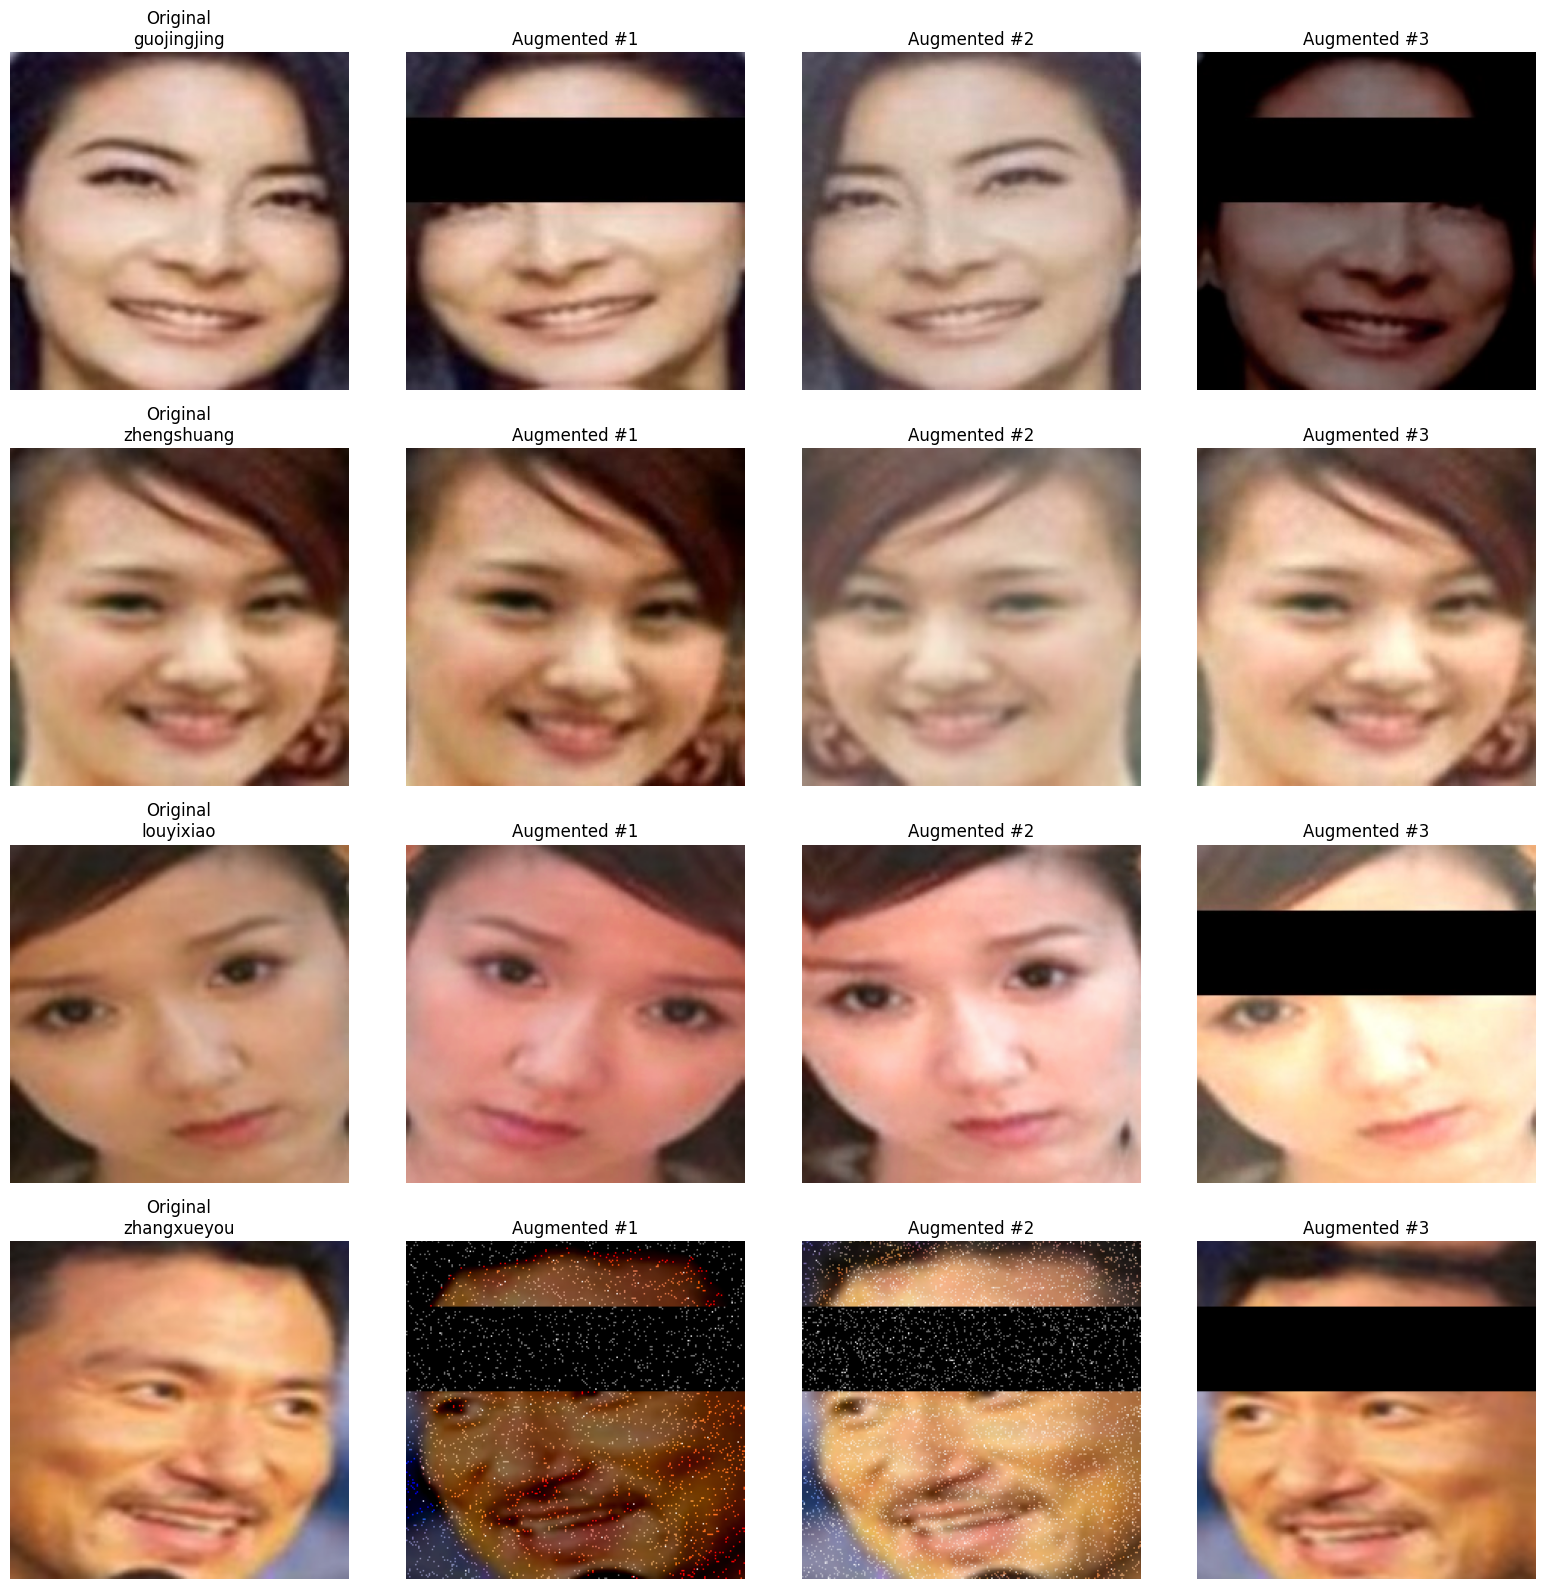

âœ… Augmentation preview complete
Left column: original image
Right columns: augmented versions


In [9]:
  print('='*70)
  print('PREVIEWING AUGMENTED SAMPLES')
  print('='*70)

  def denormalize_image(img_tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
      """Convert normalized tensor back to displayable RGB image."""
      if isinstance(img_tensor, torch.Tensor):
          img = img_tensor.detach().cpu().float().numpy()
      else:
          img = np.asarray(img_tensor, dtype=np.float32)

      if img.ndim == 3 and img.shape[0] == 3:
          img = np.transpose(img, (1, 2, 0))

      mean = np.array(mean, dtype=np.float32)
      std = np.array(std, dtype=np.float32)

      img = (img * std) + mean
      img = np.clip(img, 0, 1)
      return img


  def show_augmentation_examples(df, transform, num_samples=4, aug_per_image=3):
      if len(df) == 0:
          print("No samples available to visualize.")
          return

      sample_count = min(num_samples, len(df))
      sampled_df = df.sample(n=sample_count, random_state=42).reset_index(drop=True)

      fig, axes = plt.subplots(
          sample_count,
          aug_per_image + 1,
          figsize=(4 * (aug_per_image + 1), 4 * sample_count)
      )

      if sample_count == 1:
          axes = np.expand_dims(axes, axis=0)

      for row_idx in range(sample_count):
          row = sampled_df.iloc[row_idx]

          img_bgr = cv2.imread(row['img_path'])
          if img_bgr is None:
              for col_idx in range(aug_per_image + 1):
                  axes[row_idx, col_idx].axis('off')
              continue

          img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
          original_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

          axes[row_idx, 0].imshow(original_resized)
          axes[row_idx, 0].set_title(f"Original\n{row['identity']}")
          axes[row_idx, 0].axis('off')

          for aug_idx in range(aug_per_image):
              augmented = transform(image=img_rgb)['image']
              augmented_img = denormalize_image(augmented)

              axes[row_idx, aug_idx + 1].imshow(augmented_img)
              axes[row_idx, aug_idx + 1].set_title(f"Augmented #{aug_idx + 1}")
              axes[row_idx, aug_idx + 1].axis('off')

      plt.tight_layout()
      plt.show()


  # Preview 4 random training images, each with 3 augmented versions
  show_augmentation_examples(train_df, train_transform, num_samples=4, aug_per_image=3)

  print('âœ… Augmentation preview complete')
  print('Left column: original image')
  print('Right columns: augmented versions')

##  Cell 7: Custom Dataset Classes

In [10]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

class FaceRecognitionDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = cv2.imread(row["img_path"])
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        if self.transform:
            augmented = self.transform(image=img)
            img = augmented["image"]

        label = int(row["label"])
        mask_label = int(row["mask_label"])

        return img, label, mask_label

print("Creating datasets...")

train_dataset = FaceRecognitionDataset(train_df, transform=train_transform)
val_dataset = FaceRecognitionDataset(val_df, transform=val_transform)

class_counts = train_df["label"].value_counts().sort_index()
class_weights = 1.0 / class_counts.values
sample_weights = class_weights[train_df["label"].values]

sampler = WeightedRandomSampler(
    weights=torch.FloatTensor(sample_weights),
    num_samples=len(train_df),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("âœ… DataLoaders created.")
print(f"Train samples : {len(train_dataset)}")
print(f"Val samples   : {len(val_dataset)}")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Num identities: {train_df['label'].nunique()}")

Creating datasets...
âœ… DataLoaders created.
Train samples : 73492
Val samples   : 18374
Train batches : 4593
Val batches   : 575
Num identities: 460


## Cell 8: Model Architecture - Manual ResNet50 + ArcFace

In [11]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights


class ArcFaceHead(nn.Module):
    def __init__(self, in_features, num_classes, margin=0.5, scale=64.0, easy_margin=False):
        super().__init__()
        self.margin = margin
        self.scale = scale
        self.easy_margin = easy_margin

        self.weight = nn.Parameter(torch.empty(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.cos_margin = math.cos(margin)
        self.sin_margin = math.sin(margin)
        self.threshold = math.cos(math.pi - margin)
        self.margin_adjustment = math.sin(math.pi - margin) * margin

    def forward(self, embedding_tensor, label_tensor):
        normalized_embeddings = F.normalize(embedding_tensor, p=2, dim=1)
        normalized_weights = F.normalize(self.weight, p=2, dim=1)

        cosine_logits = F.linear(normalized_embeddings, normalized_weights)
        cosine_logits = cosine_logits.clamp(-1.0 + 1e-7, 1.0 - 1e-7)

        sine_logits = torch.sqrt(torch.clamp(1.0 - cosine_logits ** 2, min=1e-9))
        margin_logits = cosine_logits * self.cos_margin - sine_logits * self.sin_margin

        if self.easy_margin:
            margin_logits = torch.where(cosine_logits > 0, margin_logits, cosine_logits)
        else:
            margin_logits = torch.where(
                cosine_logits > self.threshold,
                margin_logits,
                cosine_logits - self.margin_adjustment,
            )

        one_hot_targets = torch.zeros_like(cosine_logits)
        one_hot_targets.scatter_(1, label_tensor.view(-1, 1).long(), 1.0)

        output_logits = (one_hot_targets * margin_logits) + ((1.0 - one_hot_targets) * cosine_logits)
        output_logits = output_logits * self.scale
        return output_logits


class BottleneckBlock(nn.Module):
    expansion = 4

    def __init__(self, in_channels, bottleneck_channels, stride=1):
        super().__init__()
        out_channels = bottleneck_channels * self.expansion

        self.conv1 = nn.Conv2d(in_channels, bottleneck_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(bottleneck_channels)

        self.conv2 = nn.Conv2d(
            bottleneck_channels,
            bottleneck_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(bottleneck_channels)

        self.conv3 = nn.Conv2d(bottleneck_channels, out_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.downsample = nn.Identity()

    def forward(self, input_tensor):
        residual_tensor = self.downsample(input_tensor)

        output_tensor = self.conv1(input_tensor)
        output_tensor = self.bn1(output_tensor)
        output_tensor = self.relu(output_tensor)

        output_tensor = self.conv2(output_tensor)
        output_tensor = self.bn2(output_tensor)
        output_tensor = self.relu(output_tensor)

        output_tensor = self.conv3(output_tensor)
        output_tensor = self.bn3(output_tensor)

        output_tensor = output_tensor + residual_tensor
        output_tensor = self.relu(output_tensor)
        return output_tensor


class ManualResNet50Backbone(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.current_channels = 64

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.layer1 = self._make_stage(bottleneck_channels=64, blocks=3, stride=1)
        self.layer2 = self._make_stage(bottleneck_channels=128, blocks=4, stride=2)
        self.layer3 = self._make_stage(bottleneck_channels=256, blocks=6, stride=2)
        self.layer4 = self._make_stage(bottleneck_channels=512, blocks=3, stride=2)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.backbone_feature_dim = 512 * BottleneckBlock.expansion

        self.embed_head = nn.Sequential(
            nn.BatchNorm1d(self.backbone_feature_dim),
            nn.Dropout(0.2),
            nn.Linear(self.backbone_feature_dim, 1024, bias=False),
            nn.BatchNorm1d(1024),
            nn.PReLU(1024),
            nn.Dropout(0.3),
            nn.Linear(1024, embed_dim, bias=False),
            nn.BatchNorm1d(embed_dim),
        )

        self._init_weights()

    def _make_stage(self, bottleneck_channels, blocks, stride):
        stage_layers = [
            BottleneckBlock(
                in_channels=self.current_channels,
                bottleneck_channels=bottleneck_channels,
                stride=stride,
            )
        ]
        self.current_channels = bottleneck_channels * BottleneckBlock.expansion

        for _ in range(1, blocks):
            stage_layers.append(
                BottleneckBlock(
                    in_channels=self.current_channels,
                    bottleneck_channels=bottleneck_channels,
                    stride=1,
                )
            )
        return nn.Sequential(*stage_layers)

    def _init_weights(self):
        for module_layer in self.modules():
            if isinstance(module_layer, nn.Conv2d):
                nn.init.kaiming_normal_(module_layer.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(module_layer, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.ones_(module_layer.weight)
                nn.init.zeros_(module_layer.bias)
            elif isinstance(module_layer, nn.Linear):
                nn.init.xavier_uniform_(module_layer.weight)
                if module_layer.bias is not None:
                    nn.init.zeros_(module_layer.bias)

    def load_imagenet_weights(self):
        torchvision_resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

        with torch.no_grad():
            self.stem[0].weight.copy_(torchvision_resnet.conv1.weight)
            self.stem[1].weight.copy_(torchvision_resnet.bn1.weight)
            self.stem[1].bias.copy_(torchvision_resnet.bn1.bias)
            self.stem[1].running_mean.copy_(torchvision_resnet.bn1.running_mean)
            self.stem[1].running_var.copy_(torchvision_resnet.bn1.running_var)
            self.stem[1].num_batches_tracked.copy_(torchvision_resnet.bn1.num_batches_tracked)

        self.layer1.load_state_dict(torchvision_resnet.layer1.state_dict())
        self.layer2.load_state_dict(torchvision_resnet.layer2.state_dict())
        self.layer3.load_state_dict(torchvision_resnet.layer3.state_dict())
        self.layer4.load_state_dict(torchvision_resnet.layer4.state_dict())

    def freeze_stages(self, freeze_to_stage=2):
        modules_to_freeze = []
        if freeze_to_stage >= 1:
            modules_to_freeze.append(self.stem)
        if freeze_to_stage >= 2:
            modules_to_freeze.append(self.layer1)
        if freeze_to_stage >= 3:
            modules_to_freeze.append(self.layer2)
        if freeze_to_stage >= 4:
            modules_to_freeze.append(self.layer3)

        for module_to_freeze in modules_to_freeze:
            module_to_freeze.eval()
            for parameter_tensor in module_to_freeze.parameters():
                parameter_tensor.requires_grad = False

    def unfreeze_all(self):
        for parameter_tensor in self.parameters():
            parameter_tensor.requires_grad = True

    def forward(self, input_tensor):
        feature_map = self.stem(input_tensor)
        feature_map = self.layer1(feature_map)
        feature_map = self.layer2(feature_map)
        feature_map = self.layer3(feature_map)
        feature_map = self.layer4(feature_map)

        pooled_features = self.global_pool(feature_map)
        flattened_features = torch.flatten(pooled_features, 1)
        embedding_tensor = self.embed_head(flattened_features)

        return embedding_tensor, flattened_features


class ArcFaceMaskModel(nn.Module):
    def __init__(self, num_identities):
        super().__init__()

        self.backbone = ManualResNet50Backbone(embed_dim=EMBED_DIM)
        self.arcface = ArcFaceHead(
            in_features=EMBED_DIM,
            num_classes=num_identities,
            margin=ARC_MARGIN,
            scale=ARC_SCALE,
        )

        self.mask_head = nn.Sequential(
            nn.Linear(self.backbone.backbone_feature_dim, 512, bias=False),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 1),
        )

    def forward(self, input_tensor, label_tensor=None):
        embedding_tensor, backbone_features = self.backbone(input_tensor)
        arcface_logits = self.arcface(embedding_tensor, label_tensor) if label_tensor is not None else None
        mask_logits = self.mask_head(backbone_features)
        return embedding_tensor, arcface_logits, mask_logits

    def get_embedding(self, input_tensor):
        embedding_tensor, _ = self.backbone(input_tensor)
        return F.normalize(embedding_tensor, p=2, dim=1)

    def detect_mask(self, input_tensor):
        _, backbone_features = self.backbone(input_tensor)
        return torch.sigmoid(self.mask_head(backbone_features))

    @torch.no_grad()
    def predict_outputs(self, input_tensor, gallery_embeddings, gallery_names, similarity_threshold=COSINE_THRESH):
        normalized_embeddings = self.get_embedding(input_tensor)
        mask_probabilities = self.detect_mask(input_tensor)

        similarity_matrix = normalized_embeddings @ gallery_embeddings.T
        best_scores, best_indices = similarity_matrix.max(dim=1)

        predictions = []
        for sample_index in range(normalized_embeddings.size(0)):
            best_score = float(best_scores[sample_index].item())
            predicted_name = gallery_names[int(best_indices[sample_index].item())]

            if best_score < similarity_threshold:
                predicted_name = "UNKNOWN"

            predictions.append(
                {
                    "predicted_name": predicted_name,
                    "similarity_score": best_score,
                    "mask_status": "Mask" if float(mask_probabilities[sample_index].item()) >= 0.5 else "No Mask",
                }
            )

        return predictions


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Initializing model...")
model = ArcFaceMaskModel(num_identities=NUM_IDENTITIES).to(DEVICE)

USE_IMAGENET_PRETRAIN = True
FREEZE_TO_STAGE = 2  # 1=stem, 2=stem+layer1, 3=+layer2, 4=+layer3

if USE_IMAGENET_PRETRAIN:
    model.backbone.load_imagenet_weights()
    model.backbone.freeze_stages(freeze_to_stage=FREEZE_TO_STAGE)
else:
    model.backbone.unfreeze_all()

with torch.no_grad():
    dummy_images = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    dummy_labels = torch.zeros(2, dtype=torch.long, device=DEVICE)
    dummy_embeddings, dummy_arc_logits, dummy_mask_logits = model(dummy_images, dummy_labels)

print("Manual ResNet50 backbone ready.")
print(f"  Embedding shape : {tuple(dummy_embeddings.shape)}")
print(f"  Arc logits shape: {tuple(dummy_arc_logits.shape)}")
print(f"  Mask logits shape: {tuple(dummy_mask_logits.shape)}")

total_parameters = sum(parameter_tensor.numel() for parameter_tensor in model.parameters())
trainable_parameters = sum(parameter_tensor.numel() for parameter_tensor in model.parameters() if
parameter_tensor.requires_grad)

print(f"Total parameters    : {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,} ({100 * trainable_parameters / total_parameters:.1f}%)")
print(f"Model device: {next(model.parameters()).device}")

Initializing model...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s] 


Manual ResNet50 backbone ready.
  Embedding shape : (2, 512)
  Arc logits shape: (2, 460)
  Mask logits shape: (2, 1)
Total parameters    : 27,423,297
Trainable parameters: 27,197,953 (99.2%)
Model device: cuda:0


## ðŸ‹ï¸ Cell 9: Training Setup â€” Loss, Optimizer, Scheduler

In [12]:
# ============================================================
# CELL 9 â€” Training Setup
# ============================================================

# â”€â”€ Loss Functions â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
criterion_arc  = nn.CrossEntropyLoss(label_smoothing=0.1)
# label_smoothing=0.1: prevents overconfidence, helps generalization
# WHY: ArcFace already provides tight margins; smoothing adds regularization

num_pos = int((train_df["mask_label"] == 1).sum())
num_neg = int((train_df["mask_label"] == 0).sum())
pos_weight = torch.tensor([num_neg / max(num_pos, 1)], dtype=torch.float32, device=DEVICE)

criterion_mask = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# BCEWithLogitsLoss = Sigmoid + BCE in one numerically stable op
# WHY not BCELoss: avoids numerical instability from sigmoid saturation

# â”€â”€ Optimizer â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# AdamW separates weight decay from gradient update (unlike Adam)
# WHY AdamW over SGD: faster convergence for fine-tuning
# WHY lr=1e-3: ArcFace papers use 0.1 with SGD; AdamW needs ~100Ã— smaller
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr           = LR,
    weight_decay = WEIGHT_DECAY,
    betas        = (0.9, 0.999),   # Adam momentum terms (default, well-tested)
    eps          = 1e-8
)

# â”€â”€ Learning Rate Schedule â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Phase 1: Linear warmup (first WARMUP_EPOCHS epochs)
#   Ramp LR from 0 â†’ LR to avoid early instability in ArcFace
# Phase 2: ReduceLROnPlateau (rest of training)
#   Reduce LR when validation loss plateaus

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor = 0.1,         # Start at 10% of LR
    end_factor   = 1.0,
    total_iters  = WARMUP_EPOCHS
)

LR_MIN = 3e-4
USE_FP16 = True

plateau_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = 'min',        # Minimize validation loss
    factor   = LR_FACTOR,    # Multiply LR by 0.5
    patience = LR_PATIENCE,  # Wait 5 epochs before reducing
    min_lr   = LR_MIN,       # Floor at 1e-6
)

# â”€â”€ Mixed Precision Scaler â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# GradScaler: prevents FP16 underflow by scaling loss before backward
# unscales before optimizer step, and adjusts scale dynamically
scaler = GradScaler(enabled=USE_FP16)

print('âœ… Training setup complete.')
print(f'  Optimizer   : AdamW(lr={LR}, wd={WEIGHT_DECAY})')
print(f'  Arc Loss    : CrossEntropy(label_smooth=0.1) Ã— Î»={LAMBDA_ARC}')
print(f'  Mask Loss   : BCEWithLogits Ã— Î»={LAMBDA_MASK}')
print(f'  Schedule    : LinearWarmup({WARMUP_EPOCHS}ep) â†’ ReduceLROnPlateau(patience={LR_PATIENCE})')
print(f'  FP16 Scaler : {USE_FP16}')
print(f'  Mask balance: pos={num_pos}, neg={num_neg}, pos_weight={pos_weight.item():.3f}')

âœ… Training setup complete.
  Optimizer   : AdamW(lr=0.001, wd=0.0005)
  Arc Loss    : CrossEntropy(label_smooth=0.1) Ã— Î»=1.0
  Mask Loss   : BCEWithLogits Ã— Î»=0.1
  Schedule    : LinearWarmup(5ep) â†’ ReduceLROnPlateau(patience=5)
  FP16 Scaler : True
  Mask balance: pos=1121, neg=72371, pos_weight=64.559


## ðŸ“Š Cell 10: Metrics â€” F1, TAR@FAR

In [13]:
# ============================================================
# CELL 10 â€” Evaluation Metrics
#
# 1. F1 Score (mask detection): harmonic mean of precision & recall
# 2. TAR@FAR=1e-4 (identity): True Accept Rate at False Accept Rate = 0.01%
#    â†’ Industry standard for face recognition security evaluation
#    â†’ FAR=1e-4 means 1 false match per 10,000 attempts
#    â†’ Higher TAR at this FAR = better recognition under occlusion
# ============================================================

def compute_f1_mask(preds_logits: np.ndarray, targets: np.ndarray) -> float:
    """
    Compute F1 score for mask detection.
    preds_logits: raw model outputs (before sigmoid)
    targets     : ground truth binary labels
    """
    preds_binary = (preds_logits > 0).astype(int)  # sigmoid(0) = 0.5 â†’ threshold
    return f1_score(targets, preds_binary, average='binary', zero_division=0)


def compute_tar_at_far(
    embeddings : np.ndarray,   # [N, 512] face embeddings
    labels     : np.ndarray,   # [N] identity labels
    far_target : float = 1e-4  # Target FAR = 0.01%
) -> float:
    """
    Compute TAR (True Accept Rate) at a given FAR (False Accept Rate).
    
    Algorithm:
    1. Compute all pairwise cosine similarities
    2. Label pairs: 1 if same identity, 0 if different
    3. Use sklearn's roc_curve to get TAR/FAR across thresholds
    4. Interpolate TAR at exact FAR=1e-4
    
    NOTE: Full pairwise O(NÂ²) â€” subsample to 5000 for speed.
    """
    # Subsample for computational efficiency
    N = min(len(embeddings), 5000)
    idx = np.random.choice(len(embeddings), N, replace=False)
    emb_sub = embeddings[idx]
    lbl_sub = labels[idx]

    # L2 normalize
    norms   = np.linalg.norm(emb_sub, axis=1, keepdims=True)
    emb_sub = emb_sub / (norms + 1e-8)

    # Sample pairs (avoid O(NÂ²) for large N)
    MAX_PAIRS = 100_000
    scores, pair_labels = [], []

    for _ in range(MAX_PAIRS):
        i, j = np.random.randint(0, N, 2)
        if i == j: continue
        cos_sim = float(np.dot(emb_sub[i], emb_sub[j]))  # Already L2 normalized
        same    = int(lbl_sub[i] == lbl_sub[j])
        scores.append(cos_sim)
        pair_labels.append(same)

    scores      = np.array(scores)
    pair_labels = np.array(pair_labels)

    # ROC curve: FPR = FAR, TPR = TAR in face recognition
    fpr, tpr, thresholds = roc_curve(pair_labels, scores)

    # Interpolate TAR at FAR = far_target
    # np.interp requires increasing x â€” fpr is already sorted ascending
    tar = float(np.interp(far_target, fpr, tpr))
    return tar


def extract_embeddings(model, loader, device) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Extract embeddings + identity labels + mask labels for a dataloader."""
    model.eval()
    all_embeddings, all_ids, all_masks = [], [], []

    with torch.no_grad():
        for imgs, ids, masks in tqdm(loader, desc='Extracting embeddings', leave=False):
            imgs = imgs.to(device)
            with autocast(enabled=USE_FP16):
                emb = model.get_embedding(imgs)  # [B, 512]
            all_embeddings.append(emb.cpu().float().numpy())
            all_ids.append(ids.numpy())
            all_masks.append(masks.numpy())

    return (
        np.concatenate(all_embeddings),
        np.concatenate(all_ids),
        np.concatenate(all_masks)
    )


print('âœ… Metrics functions defined.')
print('  - compute_f1_mask()         â†’ F1 for mask detection')
print('  - compute_tar_at_far()      â†’ TAR@FAR=1e-4 for identity')
print('  - extract_embeddings()      â†’ batch embedding extraction')

âœ… Metrics functions defined.
  - compute_f1_mask()         â†’ F1 for mask detection
  - compute_tar_at_far()      â†’ TAR@FAR=1e-4 for identity
  - extract_embeddings()      â†’ batch embedding extraction


## ðŸ‹ï¸â€â™‚ï¸ Cell 11: Training Loop

In [14]:
import time
from collections import defaultdict

def train_one_epoch(model, loader, optimizer, epoch):
    model.train()
    total_arc_loss = 0.0
    total_mask_loss = 0.0
    total_loss = 0.0
    n_batches = 0

    pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]', leave=False)

    for batch_idx, (imgs, id_labels, mask_labels) in enumerate(pbar):
        imgs = imgs.to(DEVICE, non_blocking=True)
        id_labels = id_labels.to(DEVICE, non_blocking=True)
        mask_labels = mask_labels.float().to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=USE_FP16):
            embeddings, arc_logits, mask_logits = model(imgs, id_labels)

            loss_arc = criterion_arc(arc_logits, id_labels)
            loss_mask = criterion_mask(mask_logits.squeeze(1), mask_labels)
            loss = LAMBDA_ARC * loss_arc + LAMBDA_MASK * loss_mask

        if not torch.isfinite(loss):
            raise ValueError("Non-finite training loss detected")
        if not torch.isfinite(embeddings).all():
            raise ValueError("Non-finite embeddings detected during training")
        if not torch.isfinite(arc_logits).all():
            raise ValueError("Non-finite arc logits detected during training")
        if not torch.isfinite(mask_logits).all():
            raise ValueError("Non-finite mask logits detected during training")

        if USE_FP16:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        total_arc_loss += loss_arc.item()
        total_mask_loss += loss_mask.item()
        total_loss += loss.item()
        n_batches += 1

        if batch_idx % 10 == 0:
            pbar.set_postfix({
                'arc': f'{loss_arc.item():.3f}',
                'mask': f'{loss_mask.item():.3f}',
                'tot': f'{loss.item():.3f}',
                'lr': f'{optimizer.param_groups[0]["lr"]:.2e}'
            })

    return {
        'arc_loss': total_arc_loss / n_batches,
        'mask_loss': total_mask_loss / n_batches,
        'total_loss': total_loss / n_batches,
    }


@torch.no_grad()
def validate(model, loader):
    model.eval()
    total_arc_loss = 0.0
    total_mask_loss = 0.0
    n_batches = 0
    all_mask_preds = []
    all_mask_targets = []
    all_embeddings = []
    all_id_labels = []

    for imgs, id_labels, mask_labels in tqdm(loader, desc='Validation', leave=False):
        imgs = imgs.to(DEVICE, non_blocking=True)
        id_labels = id_labels.to(DEVICE, non_blocking=True)
        mask_labels = mask_labels.float().to(DEVICE, non_blocking=True)

        with autocast(enabled=USE_FP16):
            embeddings, arc_logits, mask_logits = model(imgs, id_labels)
            loss_arc = criterion_arc(arc_logits, id_labels)
            loss_mask = criterion_mask(mask_logits.squeeze(1), mask_labels)

        if not torch.isfinite(embeddings).all():
            raise ValueError("Non-finite embeddings detected during validation")
        if arc_logits is not None and not torch.isfinite(arc_logits).all():
            raise ValueError("Non-finite arc logits detected during validation")
        if not torch.isfinite(mask_logits).all():
            raise ValueError("Non-finite mask logits detected during validation")

        total_arc_loss += loss_arc.item()
        total_mask_loss += loss_mask.item()
        n_batches += 1

        all_mask_preds.append(mask_logits.squeeze(1).cpu().float().numpy())
        all_mask_targets.append(mask_labels.cpu().numpy())
        all_embeddings.append(F.normalize(embeddings, p=2, dim=1).cpu().float().numpy())
        all_id_labels.append(id_labels.cpu().numpy())

    all_mask_preds = np.concatenate(all_mask_preds)
    all_mask_targets = np.concatenate(all_mask_targets)
    all_embeddings = np.concatenate(all_embeddings)
    all_id_labels = np.concatenate(all_id_labels)

    mask_f1 = compute_f1_mask(all_mask_preds, all_mask_targets)
    tar = compute_tar_at_far(all_embeddings, all_id_labels, far_target=1e-4)

    return {
        'arc_loss': total_arc_loss / n_batches,
        'mask_loss': total_mask_loss / n_batches,
        'total_loss': (LAMBDA_ARC * total_arc_loss + LAMBDA_MASK * total_mask_loss) / n_batches,
        'mask_f1': mask_f1,
        'tar_at_far': tar
    }


history = defaultdict(list)
best_tar = 0.0
best_epoch = 0

if "CHECKPOINT" not in globals():
    CHECKPOINT = "/kaggle/working/best_model.pth"

if "CONFIG" not in globals():
    CONFIG = {}

print(f'Starting training: {NUM_EPOCHS} epochs, batch={BATCH_SIZE}, FP16={USE_FP16}')
print('=' * 70)

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    train_metrics = train_one_epoch(model, train_loader, optimizer, epoch)
    val_metrics = validate(model, val_loader)

    if epoch < WARMUP_EPOCHS:
        warmup_scheduler.step()
    else:
        plateau_scheduler.step(val_metrics['total_loss'])

    for k, v in train_metrics.items():
        history[f'train_{k}'].append(v)
    for k, v in val_metrics.items():
        history[f'val_{k}'].append(v)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    if val_metrics['tar_at_far'] > best_tar:
        best_tar = val_metrics['tar_at_far']
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch + 1,
            'model_state': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'best_tar': best_tar,
            'config': CONFIG,
            'num_identities': NUM_IDENTITIES,
        }, CHECKPOINT)

    elapsed = time.time() - epoch_start
    print(
        f'Ep {epoch+1:3d}/{NUM_EPOCHS} | '
        f'Train: arc={train_metrics["arc_loss"]:.4f} mask={train_metrics["mask_loss"]:.4f} | '
        f'Val: arc={val_metrics["arc_loss"]:.4f} F1={val_metrics["mask_f1"]:.4f} '
        f'TAR={val_metrics["tar_at_far"]:.4f} | '
        f'LR={optimizer.param_groups[0]["lr"]:.1e} | '
        f'{elapsed:.0f}s'
        + (' ✅ BEST' if epoch + 1 == best_epoch else '')
    )

print(f'\nTraining complete. Best epoch: {best_epoch}, TAR@FAR=1e-4: {best_tar:.4f}')
print(f'Model saved to: {CHECKPOINT}')

Starting training: 50 epochs, batch=16, FP16=True


Epoch 1/50 [TRAIN]:   0%|          | 0/4593 [00:00<?, ?it/s]

KeyboardInterrupt: 

## ðŸ“ˆ Cell 12: Training Curves Visualization

In [ ]:
# ============================================================
# CELL 12 â€” Training Visualization
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('ArcFace + Mask Detection Training', fontsize=16, fontweight='bold')

epochs_range = range(1, len(history['train_arc_loss']) + 1)

# ArcFace Loss
axes[0, 0].plot(epochs_range, history['train_arc_loss'], 'b-', label='Train')
axes[0, 0].plot(epochs_range, history['val_arc_loss'],   'r--', label='Val')
axes[0, 0].set_title('ArcFace Loss (Identity)')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# Mask Loss
axes[0, 1].plot(epochs_range, history['train_mask_loss'], 'b-', label='Train')
axes[0, 1].plot(epochs_range, history['val_mask_loss'],   'r--', label='Val')
axes[0, 1].set_title('Mask Detection Loss (BCE)')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# Mask F1
axes[0, 2].plot(epochs_range, history['val_mask_f1'], 'g-', marker='o', markersize=3)
axes[0, 2].axhline(y=0.95, color='orange', linestyle='--', label='Target 95%')
axes[0, 2].set_title('Mask Detection F1 Score')
axes[0, 2].set_xlabel('Epoch'); axes[0, 2].set_ylabel('F1')
axes[0, 2].set_ylim(0, 1); axes[0, 2].legend(); axes[0, 2].grid(True, alpha=0.3)

# TAR@FAR
axes[1, 0].plot(epochs_range, history['val_tar_at_far'], 'm-', marker='o', markersize=3)
axes[1, 0].axhline(y=0.93, color='orange', linestyle='--', label='Target 93%')
axes[1, 0].set_title('TAR@FAR=1e-4 (Identity Recognition)')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('TAR')
axes[1, 0].set_ylim(0, 1); axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
axes[1, 1].plot(epochs_range, history['lr'], 'k-')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('LR')
axes[1, 1].set_yscale('log'); axes[1, 1].grid(True, alpha=0.3)

# Total Loss
axes[1, 2].plot(epochs_range, history['train_total_loss'], 'b-', label='Train Total')
axes[1, 2].plot(epochs_range, history['val_total_loss'],   'r--', label='Val Total')
axes[1, 2].set_title(f'Total Loss (Î»_arc={LAMBDA_ARC} + Î»_mask={LAMBDA_MASK})')
axes[1, 2].set_xlabel('Epoch'); axes[1, 2].set_ylabel('Loss')
axes[1, 2].legend(); axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved.')

# Checkpoint


In [14]:
import os
import torch

CHECKPOINT = None

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f == "best_model (2).pth":
            CHECKPOINT = os.path.join(root, f)
            break
    if CHECKPOINT is not None:
        break

if CHECKPOINT is None:
    raise FileNotFoundError("best_model.pth not found anywhere under /kaggle/input")

print("Using checkpoint:", CHECKPOINT)

checkpoint = torch.load(CHECKPOINT, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()

print("Loaded checkpoint successfully")
print("Epoch:", checkpoint.get("epoch", "NA"))
print("Best TAR:", checkpoint.get("best_tar", "NA"))
model.eval()

sample_imgs = []
sample_labels = []

for imgs, labels, _ in val_loader:
    sample_imgs.append(imgs)
    sample_labels.append(labels)
    if len(sample_imgs) >= 2:
        break

sample_imgs = torch.cat(sample_imgs, dim=0)[:32].to(DEVICE)
sample_labels = torch.cat(sample_labels, dim=0)[:32]

with torch.no_grad():
    emb = model.get_embedding(sample_imgs).detach().cpu()

sim = emb @ emb.T
sim_np = sim.numpy()

print("Embedding shape:", emb.shape)
print("Embedding norm mean:", emb.norm(dim=1).mean().item())
print("Similarity min:", sim_np.min())
print("Similarity max:", sim_np.max())
print("Similarity mean:", sim_np.mean())

same_scores = []
diff_scores = []

for i in range(len(sample_labels)):
    for j in range(i + 1, len(sample_labels)):
        if sample_labels[i].item() == sample_labels[j].item():
            same_scores.append(sim_np[i, j])
        else:
            diff_scores.append(sim_np[i, j])

if len(same_scores) > 0:
    print("Same-identity similarity mean:", float(np.mean(same_scores)))
    print("Same-identity similarity max :", float(np.max(same_scores)))

if len(diff_scores) > 0:
    print("Diff-identity similarity mean:", float(np.mean(diff_scores)))
    print("Diff-identity similarity min :", float(np.min(diff_scores)))
    print("Diff-identity similarity max :", float(np.max(diff_scores)))
print("Checkpoint epoch:", checkpoint.get("epoch", "NA"))
print("Checkpoint best_tar:", checkpoint.get("best_tar", "NA"))
print("Checkpoint num_identities:", checkpoint.get("num_identities", "NA"))

Using checkpoint: /kaggle/input/datasets/manuj1701/best-model-path1/best_model (2).pth
Loaded checkpoint successfully
Epoch: 45
Best TAR: 0.696
Embedding shape: torch.Size([32, 512])
Embedding norm mean: 1.0
Similarity min: -0.2777311
Similarity max: 1.0000004
Similarity mean: 0.065923154
Same-identity similarity mean: 0.6540165543556213
Same-identity similarity max : 0.6540165543556213
Diff-identity similarity mean: 0.03454269841313362
Diff-identity similarity min : -0.2777310907840729
Diff-identity similarity max : 0.3994024395942688
Checkpoint epoch: 45
Checkpoint best_tar: 0.696
Checkpoint num_identities: 460


## ðŸ§© Cell 14: SHAP Embedding Explainability

Computing SHAP values (this may take 2-5 minutes)...


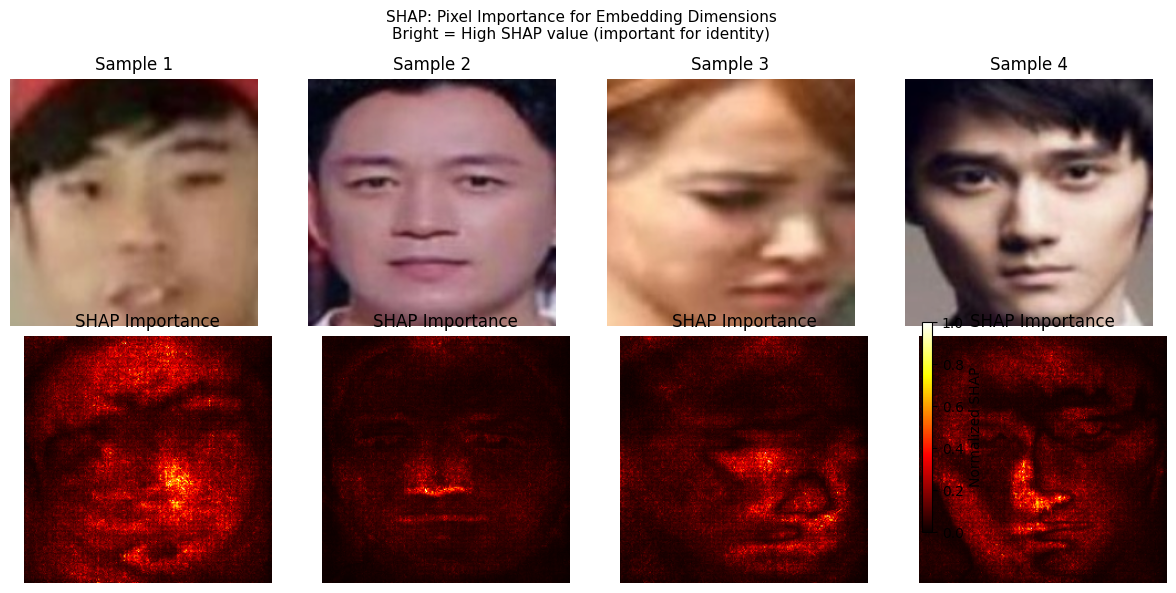

SHAP visualization saved.


In [15]:
class EmbeddingExtractorWrapper(nn.Module):
    """Wrapper to expose only embeddings (512 values) for SHAP."""
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        emb, _ = self.model.backbone(x)
        return F.normalize(emb, p=2, dim=1)


def compute_shap_embeddings(model, background_imgs, test_imgs, n_dims=10):
    emb_model = EmbeddingExtractorWrapper(model).to(DEVICE)
    emb_model.eval()

    bg_sample = background_imgs[:20].to(DEVICE)
    test_sample = test_imgs[:5].to(DEVICE)

    explainer = shap.GradientExplainer(emb_model, bg_sample)
    shap_values = explainer.shap_values(test_sample, ranked_outputs=n_dims)

    def to_numpy_safe(x):
        if torch.is_tensor(x):
            return x.detach().cpu().numpy()
        return np.asarray(x)

    if isinstance(shap_values, tuple):
        shap_values = shap_values[0]

    shap_values = to_numpy_safe(shap_values)

      # Handle common SHAP output layouts
    if shap_values.ndim == 5:
          # [N, C, H, W, D] or [N, H, W, C, D]
        if shap_values.shape[1] == 3:
            shap_agg = np.mean(np.abs(shap_values), axis=-1)   # -> [N, C, H, W]
            shap_map = shap_agg.sum(axis=1)                    # -> [N, H, W]
        elif shap_values.shape[3] == 3:
            shap_agg = np.mean(np.abs(shap_values), axis=-1)   # -> [N, H, W, C]
            shap_map = shap_agg.sum(axis=-1)                   # -> [N, H, W]
        else:
            raise ValueError(f"Unexpected 5D SHAP shape: {shap_values.shape}")

    elif shap_values.ndim == 4:
          # [N, C, H, W] or [N, H, W, C]
        if shap_values.shape[1] == 3:
            shap_map = np.abs(shap_values).sum(axis=1)
        elif shap_values.shape[-1] == 3:
            shap_map = np.abs(shap_values).sum(axis=-1)
        else:
            raise ValueError(f"Unexpected 4D SHAP shape: {shap_values.shape}")

    else:
        raise ValueError(f"Unexpected SHAP output shape: {shap_values.shape}")

    return shap_map, test_sample.detach().cpu().numpy()


def visualize_shap(shap_maps, imgs_np, n_samples=4):
    n_samples = min(n_samples, shap_maps.shape[0])

    fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 3, 6))
    fig.suptitle(
        'SHAP: Pixel Importance for Embedding Dimensions\n'
        'Bright = High SHAP value (important for identity)',
        fontsize=11
    )

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    if n_samples == 1:
        axes = np.array(axes).reshape(2, 1)

    for i in range(n_samples):
        img_show = (imgs_np[i].transpose(1, 2, 0) * std + mean).clip(0, 1)
        shap_show = shap_maps[i]
        shap_norm = (shap_show - shap_show.min()) / (shap_show.max() - shap_show.min() + 1e-8)

        axes[0, i].imshow(img_show)
        axes[0, i].set_title(f'Sample {i+1}')
        axes[0, i].axis('off')

        im = axes[1, i].imshow(shap_norm, cmap='hot', vmin=0, vmax=1)
        axes[1, i].set_title('SHAP Importance')
        axes[1, i].axis('off')

    plt.colorbar(im, ax=axes[1, :], location='right', label='Normalized SHAP')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'shap_embeddings.png'), dpi=150, bbox_inches='tight')
    plt.show()


print('Computing SHAP values (this may take 2-5 minutes)...')
all_val_imgs = []

for imgs, _, _ in val_loader:
    all_val_imgs.append(imgs)
    if len(all_val_imgs) >= 3:
        break

all_val_imgs = torch.cat(all_val_imgs, dim=0)

if all_val_imgs.shape[0] < 25:
    raise ValueError('Need at least 25 images from val_loader for SHAP.')

try:
    shap_maps, imgs_np = compute_shap_embeddings(
        model,
        background_imgs=all_val_imgs[:20],
        test_imgs=all_val_imgs[20:25],
        n_dims=10
    )
    visualize_shap(shap_maps, imgs_np)
    print('SHAP visualization saved.')
except Exception as e:
    print(f'SHAP failed (possibly OOM): {e}')
    print('Skipping SHAP visualization.')

## ðŸ” Cell 15: Full Inference Pipeline

In [16]:
# ============================================================
# CELL 15 - Full Inference Pipeline
# Steps:
#   1. InsightFace face detection and crop
#   2. Mask/no-mask classification
#   3. Manual ResNet50 embedding extraction
#   4. Cosine similarity identity matching
#   5. Final outputs: predicted_name, similarity_score, mask_status
# ============================================================

class FaceRecognitionPipeline:
    """
    End-to-end pipeline for face recognition despite occlusion.

    Final user-facing outputs per query image:
      - predicted_name
      - similarity_score
      - mask_status
    """

    def __init__(self, model, face_app, device, threshold=COSINE_THRESH):
        self.model = model.eval().to(device)
        self.face_app = face_app
        self.device = device
        self.threshold = threshold
        self.gallery = {}
        self.transform = val_transform

    def preprocess(self, img_path: str) -> Optional[torch.Tensor]:
      img = cv2.imread(img_path)
      if img is None:
          return None

      rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
      rgb = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE))

      augmented = self.transform(image=rgb)
      return augmented['image'].unsqueeze(0)

    @torch.no_grad()
    def get_embedding(self, img_path: str) -> Optional[np.ndarray]:
        tensor = self.preprocess(img_path)
        if tensor is None:
            return None
        tensor = tensor.to(self.device)
        with autocast(enabled=USE_FP16):
            emb = self.model.get_embedding(tensor)
        return emb.cpu().float().numpy()[0]

    @torch.no_grad()
    def detect_mask(self, img_path: str) -> Tuple[bool, float]:
        tensor = self.preprocess(img_path)
        if tensor is None:
            return False, 0.0
        tensor = tensor.to(self.device)
        with autocast(enabled=USE_FP16):
            prob = self.model.detect_mask(tensor)
        conf = float(prob.item())
        return conf >= 0.5, conf

    def register(self, name: str, img_paths: List[str]):
        embeddings = []
        for path in img_paths:
            emb = self.get_embedding(path)
            if emb is not None:
                embeddings.append(emb)
        if embeddings:
            mean_emb = np.mean(embeddings, axis=0)
            mean_emb = mean_emb / (np.linalg.norm(mean_emb) + 1e-8)
            self.gallery[name] = mean_emb
            print(f'  Registered: {name} ({len(embeddings)} images)')
        else:
            print(f'  WARNING: No valid faces found for {name}')

    def identify(self, img_path: str) -> Dict:
        result = {
            'predicted_name': 'UNKNOWN',
            'similarity_score': 0.0,
            'mask_status': 'No Mask',
            'mask_confidence': 0.0,
            'above_threshold': False
        }

        is_masked, mask_conf = self.detect_mask(img_path)
        result['mask_status'] = 'Mask' if is_masked else 'No Mask'
        result['mask_confidence'] = mask_conf

        query_emb = self.get_embedding(img_path)
        if query_emb is None or not self.gallery:
            return result

        best_name = 'UNKNOWN'
        best_score = -1.0
        for name, ref_emb in self.gallery.items():
            sim = float(np.dot(query_emb, ref_emb))
            if sim > best_score:
                best_score = sim
                best_name = name

        result['similarity_score'] = best_score
        result['above_threshold'] = best_score >= self.threshold
        if result['above_threshold']:
            result['predicted_name'] = best_name

        return result

# Testing on Custome dataset

In [17]:
from sklearn.metrics import f1_score
import os
import glob
import json
import pandas as pd
import torch

print('=' * 70)
print('CUSTOM DATASET TESTING')
print('=' * 70)

SIMILARITY_THRESHOLD = 0.38
CUSTOM_FACE_DIR = "/kaggle/input/datasets/manuj1701/personal-dataset/Deep Learning Dataset/face_dataset"


def build_custom_dataframe(root_dir: str, mask_label: int = 0) -> pd.DataFrame:
    records = []

    if not os.path.isdir(root_dir):
        raise FileNotFoundError(f"Folder not found: {root_dir}")

    for person in sorted(os.listdir(root_dir)):
        person_dir = os.path.join(root_dir, person)
        if not os.path.isdir(person_dir):
            continue

        for img_path in glob.glob(os.path.join(person_dir, "*")):
            if img_path.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
                records.append({
                    "img_path": img_path,
                    "identity": person,
                    "mask_label": mask_label
                })

    return pd.DataFrame(records)


def split_gallery_query(group_df: pd.DataFrame, gallery_fraction: float = 0.5):
    group_df = group_df.sample(frac=1.0, random_state=42).reset_index(drop=True)
    n = len(group_df)

    if n < 2:
        return None, None

    n_gallery = max(1, int(round(n * gallery_fraction)))
    n_gallery = min(n_gallery, n - 1)

    gallery_df = group_df.iloc[:n_gallery].copy()
    query_df = group_df.iloc[n_gallery:].copy()

    if len(query_df) == 0:
        return None, None

    return gallery_df, query_df


eval_df = build_custom_dataframe(CUSTOM_FACE_DIR, mask_label=0)

print(f"Total custom images   : {len(eval_df)}")
print(f"Unique identities     : {eval_df['identity'].nunique()}")

gallery_parts = []
query_parts = []

for identity, grp in eval_df.groupby("identity"):
    g_df, q_df = split_gallery_query(grp, gallery_fraction=0.5)
    if g_df is None or q_df is None:
        continue
    gallery_parts.append(g_df)
    query_parts.append(q_df)

if len(gallery_parts) == 0 or len(query_parts) == 0:
    raise ValueError("Could not build custom gallery/query split. Need at least 2 images per person.")

gallery_df = pd.concat(gallery_parts, ignore_index=True)
query_df = pd.concat(query_parts, ignore_index=True)

print(f"Gallery images        : {len(gallery_df)}")
print(f"Query images          : {len(query_df)}")
print(f"Gallery identities    : {gallery_df['identity'].nunique()}")

checkpoint = torch.load(CHECKPOINT, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint.get('epoch', 'NA')}")
print(f"Checkpoint best TAR   : {checkpoint.get('best_tar', 'NA')}")

pipeline = FaceRecognitionPipeline(
    model=model,
    face_app=face_app,
    device=DEVICE,
    threshold=SIMILARITY_THRESHOLD,
)

print("\nBuilding custom gallery...")
for identity, grp in gallery_df.groupby("identity"):
    pipeline.register(identity, grp["img_path"].tolist())

if len(pipeline.gallery) == 0:
    raise ValueError("Gallery is empty after registration.")

print("\nRunning custom query testing...")
pred_rows = []

for row in query_df.itertuples(index=False):
    pred = pipeline.identify(row.img_path)
    pred_mask_label = 1 if pred["mask_status"] == "Mask" else 0

    pred_rows.append({
        "img_path": row.img_path,
        "identity": row.identity,
        "mask_label": int(row.mask_label),
        "predicted_name": pred["predicted_name"],
        "similarity_score": float(pred["similarity_score"]),
        "mask_status": pred["mask_status"],
        "mask_confidence": float(pred["mask_confidence"]),
        "above_threshold": bool(pred["above_threshold"]),
        "correct_identity": int(pred["predicted_name"] == row.identity),
        "pred_mask_label": pred_mask_label,
    })

pred_df = pd.DataFrame(pred_rows)

if pred_df.empty:
    raise ValueError("No predictions were produced.")

identity_accuracy = float(pred_df["correct_identity"].mean())
unknown_rate = float((pred_df["predicted_name"] == "UNKNOWN").mean())
mean_similarity = float(pred_df["similarity_score"].mean())

known_df = pred_df[pred_df["predicted_name"] != "UNKNOWN"]
known_only_accuracy = float((known_df["predicted_name"] == known_df["identity"]).mean()) if len(known_df) > 0 else 0.0

print("\n" + "=" * 60)
print("CUSTOM DATASET RESULTS")
print("=" * 60)
print(f"Query samples         : {len(pred_df)}")
print(f"Identity accuracy     : {identity_accuracy:.4f} ({identity_accuracy*100:.2f}%)")
print(f"Known-only accuracy   : {known_only_accuracy:.4f} ({known_only_accuracy*100:.2f}%)")
print(f"Unknown rate          : {unknown_rate:.4f} ({unknown_rate*100:.2f}%)")
print(f"Mean similarity score : {mean_similarity:.4f}")
print(f"Similarity threshold  : {SIMILARITY_THRESHOLD}")
print("=" * 60)

print("\nAll predictions:")
print(
    pred_df[
        ["identity", "predicted_name", "similarity_score", "mask_status", "above_threshold"]
    ].to_string(index=False)
)

pred_csv = os.path.join(OUTPUT_DIR, "custom_dataset_predictions.csv")
summary_json = os.path.join(OUTPUT_DIR, "custom_dataset_summary.json")

pred_df.to_csv(pred_csv, index=False)

test_summary = {
    "source": "custom_face_dataset",
    "num_gallery_images": int(len(gallery_df)),
    "num_query_images": int(len(pred_df)),
    "num_gallery_identities": int(gallery_df["identity"].nunique()),
    "identity_accuracy": identity_accuracy,
    "known_only_accuracy": known_only_accuracy,
    "unknown_rate": unknown_rate,
    "mean_similarity_score": mean_similarity,
    "similarity_threshold": float(SIMILARITY_THRESHOLD),
}

with open(summary_json, "w") as f:
    json.dump(test_summary, f, indent=2)

print("\nSaved:")
print(pred_csv)
print(summary_json)

CUSTOM DATASET TESTING
Total custom images   : 109
Unique identities     : 6
Gallery images        : 57
Query images          : 52
Gallery identities    : 6
Loaded checkpoint from epoch 45
Checkpoint best TAR   : 0.696

Building custom gallery...
  Registered: akshat (8 images)
  Registered: dewangi (8 images)
  Registered: jaski (8 images)
  Registered: manuj (8 images)
  Registered: shivam (8 images)


Invalid SOS parameters for sequential JPEG


  Registered: varan (17 images)

Running custom query testing...

CUSTOM DATASET RESULTS
Query samples         : 52
Identity accuracy     : 0.7308 (73.08%)
Known-only accuracy   : 0.7755 (77.55%)
Unknown rate          : 0.0577 (5.77%)
Mean similarity score : 0.5609
Similarity threshold  : 0.38

All predictions:
identity predicted_name  similarity_score mask_status  above_threshold
  akshat          jaski          0.414364        Mask             True
  akshat        UNKNOWN          0.188291     No Mask            False
  akshat          manuj          0.618418        Mask             True
  akshat         akshat          0.606081        Mask             True
  akshat          varan          0.393617        Mask             True
  akshat         akshat          0.672914        Mask             True
  akshat         akshat          0.723740     No Mask             True
 dewangi        dewangi          0.463194     No Mask             True
 dewangi        dewangi          0.488507     No

## ðŸ“Š Cell 16: Final Evaluation on Test Set

In [18]:
from sklearn.metrics import f1_score
import os
import json
import pandas as pd
import torch

print('=' * 70)
print('PHASE 6: RMFRD TESTING ON VALIDATION SET')
print('=' * 70)

SIMILARITY_THRESHOLD = COSINE_THRESH


def split_gallery_query(group_df: pd.DataFrame, gallery_fraction: float = 0.5):
    group_df = group_df.sample(frac=1.0, random_state=42).reset_index(drop=True)

    n = len(group_df)
    if n < 2:
        return None, None

    n_gallery = max(1, int(round(n * gallery_fraction)))
    n_gallery = min(n_gallery, n - 1)

    gallery_df = group_df.iloc[:n_gallery].copy()
    query_df = group_df.iloc[n_gallery:].copy()

    if len(query_df) == 0:
        return None, None

    return gallery_df, query_df


  # Use RMFRD validation split only
eval_df = val_df[['img_path', 'identity', 'mask_label']].copy()

print(f'Total RMFRD eval images : {len(eval_df)}')
print(f'Unique identities       : {eval_df["identity"].nunique()}')

gallery_parts = []
query_parts = []

for identity, grp in eval_df.groupby('identity'):
    g_df, q_df = split_gallery_query(grp, gallery_fraction=0.5)
    if g_df is None or q_df is None:
        continue
    gallery_parts.append(g_df)
    query_parts.append(q_df)

if len(gallery_parts) == 0 or len(query_parts) == 0:
    raise ValueError('Could not build gallery/query split from val_df.')

gallery_df = pd.concat(gallery_parts, ignore_index=True)
query_df = pd.concat(query_parts, ignore_index=True)

print(f'Gallery images          : {len(gallery_df)}')
print(f'Query images            : {len(query_df)}')
print(f'Gallery identities      : {gallery_df["identity"].nunique()}')

  # Load best checkpoint
checkpoint = torch.load(CHECKPOINT, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()

print(f'Loaded checkpoint from epoch {checkpoint.get("epoch", "NA")}')

pipeline = FaceRecognitionPipeline(
    model=model,
    face_app=face_app,
    device=DEVICE,
    threshold=SIMILARITY_THRESHOLD,
)

print('\nBuilding RMFRD gallery...')
for identity, grp in gallery_df.groupby('identity'):
    pipeline.register(identity, grp['img_path'].tolist())

if len(pipeline.gallery) == 0:
    raise ValueError('Gallery is empty after registration.')

print('\nRunning RMFRD query testing...')
pred_rows = []

for row in query_df.itertuples(index=False):
    pred = pipeline.identify(row.img_path)
    pred_mask_label = 1 if pred['mask_status'] == 'Mask' else 0

    pred_rows.append({
        'img_path': row.img_path,
        'identity': row.identity,
        'mask_label': int(row.mask_label),
        'predicted_name': pred['predicted_name'],
        'similarity_score': float(pred['similarity_score']),
        'mask_status': pred['mask_status'],
        'mask_confidence': float(pred['mask_confidence']),
        'above_threshold': bool(pred['above_threshold']),
        'correct_identity': int(pred['predicted_name'] == row.identity),
        'pred_mask_label': pred_mask_label,
    })

pred_df = pd.DataFrame(pred_rows)

if pred_df.empty:
    raise ValueError('No predictions were produced.')

identity_accuracy = float(pred_df['correct_identity'].mean())
unknown_rate = float((pred_df['predicted_name'] == 'UNKNOWN').mean())
mask_f1 = float(f1_score(pred_df['mask_label'], pred_df['pred_mask_label'], zero_division=0))
mean_similarity = float(pred_df['similarity_score'].mean())

known_df = pred_df[pred_df['predicted_name'] != 'UNKNOWN']
known_only_accuracy = float((known_df['predicted_name'] == known_df['identity']).mean()) if len(known_df) > 0 else 0.0

print('\n' + '=' * 60)
print('RMFRD GALLERY-BASED TEST RESULTS')
print('=' * 60)
print(f'Query samples         : {len(pred_df)}')
print(f'Identity accuracy     : {identity_accuracy:.4f} ({identity_accuracy*100:.2f}%)')
print(f'Known-only accuracy   : {known_only_accuracy:.4f} ({known_only_accuracy*100:.2f}%)')
print(f'Unknown rate          : {unknown_rate:.4f} ({unknown_rate*100:.2f}%)')
print(f'Mask F1 score         : {mask_f1:.4f} ({mask_f1*100:.2f}%)')
print(f'Mean similarity score : {mean_similarity:.4f}')
print(f'Similarity threshold  : {SIMILARITY_THRESHOLD}')
print('=' * 60)

print('\nSample predictions:')
print(
    pred_df[
        ['identity', 'predicted_name', 'similarity_score', 'mask_status', 'above_threshold']
    ].head(10).to_string(index=False)
)

pred_csv = os.path.join(OUTPUT_DIR, 'rmfrd_test_predictions.csv')
summary_json = os.path.join(OUTPUT_DIR, 'rmfrd_test_summary.json')

pred_df.to_csv(pred_csv, index=False)

test_summary = {
    'source': 'rmfrd_val_df',
    'num_gallery_images': int(len(gallery_df)),
    'num_query_images': int(len(pred_df)),
    'num_gallery_identities': int(gallery_df['identity'].nunique()),
    'identity_accuracy': identity_accuracy,
    'known_only_accuracy': known_only_accuracy,
    'unknown_rate': unknown_rate,
    'mask_f1': mask_f1,
    'mean_similarity_score': mean_similarity,
    'similarity_threshold': float(SIMILARITY_THRESHOLD),
}

with open(summary_json, 'w') as f:
    json.dump(test_summary, f, indent=2)

print('\nSaved:')
print(pred_csv)
print(summary_json)

PHASE 6: RMFRD TESTING ON VALIDATION SET
Total RMFRD eval images : 18374
Unique identities       : 460
Gallery images          : 9183
Query images            : 9191
Gallery identities      : 460
Loaded checkpoint from epoch 27

Building RMFRD gallery...
  Registered: aidai (18 images)
  Registered: anhu (24 images)
  Registered: axin (11 images)
  Registered: baibaihe (25 images)
  Registered: baijingting (18 images)
  Registered: baike (18 images)
  Registered: baobeier (14 images)
  Registered: baojianfeng (26 images)
  Registered: benxi (19 images)
  Registered: caiguoqing (16 images)
  Registered: caihancen (14 images)
  Registered: caiyilin (17 images)
  Registered: caizhuoyan (22 images)
  Registered: caobingkun (28 images)
  Registered: caoying (28 images)
  Registered: caoyunjin (24 images)
  Registered: cengyongti (26 images)
  Registered: changshilei (20 images)
  Registered: changyuan (16 images)
  Registered: chenbailin (10 images)
  Registered: chenderong (21 images)
  Reg

KeyboardInterrupt: 

# 16B The masked dataset testing


In [ ]:
from sklearn.metrics import f1_score
import os
import glob
import json
import pandas as pd
import torch

print('=' * 70)
print('PHASE 6B: MASKED-ONLY RMFRD TESTING')
print('=' * 70)

SIMILARITY_THRESHOLD = COSINE_THRESH

MASKED_ONLY_DIR = "/kaggle/input/datasets/muhammeddalkran/masked-facerecognition/AFDB_masked_face_dataset/AFDB_masked_face_dataset"


def build_masked_only_dataframe(masked_dir: str) -> pd.DataFrame:
    records = []

    if not os.path.isdir(masked_dir):
        raise FileNotFoundError(f"Masked dataset folder not found: {masked_dir}")

    for person in sorted(os.listdir(masked_dir)):
        person_dir = os.path.join(masked_dir, person)
        if not os.path.isdir(person_dir):
            continue

        for img_path in glob.glob(os.path.join(person_dir, "*")):
            if img_path.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
                records.append({
                    "img_path": img_path,
                    "identity": person,
                    "mask_label": 1
                })

    return pd.DataFrame(records)


def split_gallery_query(group_df: pd.DataFrame, gallery_fraction: float = 0.5):
    group_df = group_df.sample(frac=1.0, random_state=42).reset_index(drop=True)

    n = len(group_df)
    if n < 2:
        return None, None

    n_gallery = max(1, int(round(n * gallery_fraction)))
    n_gallery = min(n_gallery, n - 1)

    gallery_df = group_df.iloc[:n_gallery].copy()
    query_df = group_df.iloc[n_gallery:].copy()

    if len(query_df) == 0:
        return None, None

    return gallery_df, query_df


eval_df = build_masked_only_dataframe(MASKED_ONLY_DIR)

print(f"Total masked images   : {len(eval_df)}")
print(f"Unique identities     : {eval_df['identity'].nunique()}")

gallery_parts = []
query_parts = []

for identity, grp in eval_df.groupby("identity"):
    g_df, q_df = split_gallery_query(grp, gallery_fraction=0.5)
    if g_df is None or q_df is None:
        continue
    gallery_parts.append(g_df)
    query_parts.append(q_df)

if len(gallery_parts) == 0 or len(query_parts) == 0:
    raise ValueError("Could not build masked gallery/query split.")

gallery_df = pd.concat(gallery_parts, ignore_index=True)
query_df = pd.concat(query_parts, ignore_index=True)

print(f"Gallery images        : {len(gallery_df)}")
print(f"Query images          : {len(query_df)}")
print(f"Gallery identities    : {gallery_df['identity'].nunique()}")

checkpoint = torch.load(CHECKPOINT, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint.get('epoch', 'NA')}")
print(f"Checkpoint best TAR   : {checkpoint.get('best_tar', 'NA')}")

pipeline = FaceRecognitionPipeline(
    model=model,
    face_app=face_app,
    device=DEVICE,
    threshold=SIMILARITY_THRESHOLD,
)

print("\nBuilding masked-only gallery...")
for identity, grp in gallery_df.groupby("identity"):
    pipeline.register(identity, grp["img_path"].tolist())

if len(pipeline.gallery) == 0:
    raise ValueError("Gallery is empty after registration.")

print("\nRunning masked-only query testing...")
pred_rows = []

for row in query_df.itertuples(index=False):
    pred = pipeline.identify(row.img_path)
    pred_mask_label = 1 if pred["mask_status"] == "Mask" else 0

    pred_rows.append({
        "img_path": row.img_path,
        "identity": row.identity,
        "mask_label": int(row.mask_label),
        "predicted_name": pred["predicted_name"],
        "similarity_score": float(pred["similarity_score"]),
        "mask_status": pred["mask_status"],
        "mask_confidence": float(pred["mask_confidence"]),
        "above_threshold": bool(pred["above_threshold"]),
        "correct_identity": int(pred["predicted_name"] == row.identity),
        "pred_mask_label": pred_mask_label,
    })

pred_df = pd.DataFrame(pred_rows)

if pred_df.empty:
    raise ValueError("No predictions were produced.")

identity_accuracy = float(pred_df["correct_identity"].mean())
unknown_rate = float((pred_df["predicted_name"] == "UNKNOWN").mean())
mask_f1 = float(f1_score(pred_df["mask_label"], pred_df["pred_mask_label"], zero_division=0))
mean_similarity = float(pred_df["similarity_score"].mean())

known_df = pred_df[pred_df["predicted_name"] != "UNKNOWN"]
known_only_accuracy = float((known_df["predicted_name"] == known_df["identity"]).mean()) if len(known_df) > 0 else 0.0

print("\n" + "=" * 60)
print("MASKED-ONLY RMFRD TEST RESULTS")
print("=" * 60)
print(f"Query samples         : {len(pred_df)}")
print(f"Identity accuracy     : {identity_accuracy:.4f} ({identity_accuracy*100:.2f}%)")
print(f"Known-only accuracy   : {known_only_accuracy:.4f} ({known_only_accuracy*100:.2f}%)")
print(f"Unknown rate          : {unknown_rate:.4f} ({unknown_rate*100:.2f}%)")
print(f"Mask F1 score         : {mask_f1:.4f} ({mask_f1*100:.2f}%)")
print(f"Mean similarity score : {mean_similarity:.4f}")
print(f"Similarity threshold  : {SIMILARITY_THRESHOLD}")
print("=" * 60)

print("\nSample predictions:")
print(
    pred_df[
        ["identity", "predicted_name", "similarity_score", "mask_status", "above_threshold"]
    ].head(10).to_string(index=False)
)

pred_csv = os.path.join(OUTPUT_DIR, "rmfrd_masked_only_test_predictions.csv")
summary_json = os.path.join(OUTPUT_DIR, "rmfrd_masked_only_test_summary.json")

pred_df.to_csv(pred_csv, index=False)

test_summary = {
    "source": "rmfrd_masked_only",
    "num_gallery_images": int(len(gallery_df)),
    "num_query_images": int(len(pred_df)),
    "num_gallery_identities": int(gallery_df["identity"].nunique()),
    "identity_accuracy": identity_accuracy,
    "known_only_accuracy": known_only_accuracy,
    "unknown_rate": unknown_rate,
    "mask_f1": mask_f1,
    "mean_similarity_score": mean_similarity,
    "similarity_threshold": float(SIMILARITY_THRESHOLD),
}

with open(summary_json, "w") as f:
    json.dump(test_summary, f, indent=2)

print("\nSaved:")
print(pred_csv)
print(summary_json)

# 16C Unmasked Gallery/Masked Query

In [18]:
from sklearn.metrics import f1_score
import os
import glob
import json
import pandas as pd
import torch

print('=' * 70)
print('PHASE 6C: UNMASKED GALLERY / MASKED QUERY TEST')
print('=' * 70)

SIMILARITY_THRESHOLD = COSINE_THRESH

UNMASKED_DIR = "/kaggle/input/datasets/muhammeddalkran/masked-facerecognition/AFDB_face_dataset/AFDB_face_dataset"
MASKED_DIR = "/kaggle/input/datasets/muhammeddalkran/masked-facerecognition/AFDB_masked_face_dataset/AFDB_masked_face_dataset"


def build_identity_dataframe(root_dir: str, mask_label: int) -> pd.DataFrame:
    records = []

    if not os.path.isdir(root_dir):
        raise FileNotFoundError(f"Folder not found: {root_dir}")

    for person in sorted(os.listdir(root_dir)):
        person_dir = os.path.join(root_dir, person)
        if not os.path.isdir(person_dir):
            continue

        for img_path in glob.glob(os.path.join(person_dir, "*")):
            if img_path.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
                records.append({
                    "img_path": img_path,
                    "identity": person,
                    "mask_label": mask_label
                })

    return pd.DataFrame(records)


def split_gallery_only(group_df: pd.DataFrame, gallery_fraction: float = 0.5):
    group_df = group_df.sample(frac=1.0, random_state=42).reset_index(drop=True)
    n = len(group_df)

    if n < 1:
        return None

    n_gallery = max(1, int(round(n * gallery_fraction)))
    n_gallery = min(n_gallery, n)

    return group_df.iloc[:n_gallery].copy()


gallery_source_df = build_identity_dataframe(UNMASKED_DIR, mask_label=0)
query_df = build_identity_dataframe(MASKED_DIR, mask_label=1)

common_identities = sorted(
    set(gallery_source_df["identity"].unique()) & set(query_df["identity"].unique())
)

gallery_source_df = gallery_source_df[gallery_source_df["identity"].isin(common_identities)].reset_index(drop=True)
query_df = query_df[query_df["identity"].isin(common_identities)].reset_index(drop=True)

gallery_parts = []
for identity, grp in gallery_source_df.groupby("identity"):
    g_df = split_gallery_only(grp, gallery_fraction=0.5)
    if g_df is not None and len(g_df) > 0:
        gallery_parts.append(g_df)

if len(gallery_parts) == 0:
    raise ValueError("No gallery images could be created from unmasked dataset.")

gallery_df = pd.concat(gallery_parts, ignore_index=True)

print(f"Common identities      : {len(common_identities)}")
print(f"Gallery images         : {len(gallery_df)}")
print(f"Masked query images    : {len(query_df)}")
print(f"Gallery identities     : {gallery_df['identity'].nunique()}")

checkpoint = torch.load(CHECKPOINT, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint.get('epoch', 'NA')}")
print(f"Checkpoint best TAR    : {checkpoint.get('best_tar', 'NA')}")

pipeline = FaceRecognitionPipeline(
    model=model,
    face_app=face_app,
    device=DEVICE,
    threshold=SIMILARITY_THRESHOLD,
)

print("\nBuilding unmasked gallery...")
for identity, grp in gallery_df.groupby("identity"):
    pipeline.register(identity, grp["img_path"].tolist())

if len(pipeline.gallery) == 0:
    raise ValueError("Gallery is empty after registration.")

print("\nRunning masked query testing...")
pred_rows = []

for row in query_df.itertuples(index=False):
    pred = pipeline.identify(row.img_path)
    pred_mask_label = 1 if pred["mask_status"] == "Mask" else 0

    pred_rows.append({
        "img_path": row.img_path,
        "identity": row.identity,
        "mask_label": int(row.mask_label),
        "predicted_name": pred["predicted_name"],
        "similarity_score": float(pred["similarity_score"]),
        "mask_status": pred["mask_status"],
        "mask_confidence": float(pred["mask_confidence"]),
        "above_threshold": bool(pred["above_threshold"]),
        "correct_identity": int(pred["predicted_name"] == row.identity),
        "pred_mask_label": pred_mask_label,
    })

pred_df = pd.DataFrame(pred_rows)

if pred_df.empty:
    raise ValueError("No predictions were produced.")

identity_accuracy = float(pred_df["correct_identity"].mean())
unknown_rate = float((pred_df["predicted_name"] == "UNKNOWN").mean())
mask_f1 = float(f1_score(pred_df["mask_label"], pred_df["pred_mask_label"], zero_division=0))
mean_similarity = float(pred_df["similarity_score"].mean())

known_df = pred_df[pred_df["predicted_name"] != "UNKNOWN"]
known_only_accuracy = float((known_df["predicted_name"] == known_df["identity"]).mean()) if len(known_df) > 0 else 0.0

print("\n" + "=" * 60)
print("UNMASKED GALLERY / MASKED QUERY RESULTS")
print("=" * 60)
print(f"Query samples         : {len(pred_df)}")
print(f"Identity accuracy     : {identity_accuracy:.4f} ({identity_accuracy*100:.2f}%)")
print(f"Known-only accuracy   : {known_only_accuracy:.4f} ({known_only_accuracy*100:.2f}%)")
print(f"Unknown rate          : {unknown_rate:.4f} ({unknown_rate*100:.2f}%)")
print(f"Mask F1 score         : {mask_f1:.4f} ({mask_f1*100:.2f}%)")
print(f"Mean similarity score : {mean_similarity:.4f}")
print(f"Similarity threshold  : {SIMILARITY_THRESHOLD}")
print("=" * 60)

print("\nSample predictions:")
print(
    pred_df[
        ["identity", "predicted_name", "similarity_score", "mask_status", "above_threshold"]
    ].head(10).to_string(index=False)
)

pred_csv = os.path.join(OUTPUT_DIR, "rmfrd_unmasked_gallery_masked_query_predictions.csv")
summary_json = os.path.join(OUTPUT_DIR, "rmfrd_unmasked_gallery_masked_query_summary.json")

pred_df.to_csv(pred_csv, index=False)

test_summary = {
    "source": "rmfrd_unmasked_gallery_masked_query",
    "num_gallery_images": int(len(gallery_df)),
    "num_query_images": int(len(pred_df)),
    "num_gallery_identities": int(gallery_df["identity"].nunique()),
    "identity_accuracy": identity_accuracy,
    "known_only_accuracy": known_only_accuracy,
    "unknown_rate": unknown_rate,
    "mask_f1": mask_f1,
    "mean_similarity_score": mean_similarity,
    "similarity_threshold": float(SIMILARITY_THRESHOLD),
}

with open(summary_json, "w") as f:
    json.dump(test_summary, f, indent=2)

print("\nSaved:")
print(pred_csv)
print(summary_json)

PHASE 6C: UNMASKED GALLERY / MASKED QUERY TEST
Common identities      : 377
Gallery images         : 37915
Masked query images    : 1398
Gallery identities     : 377
Loaded checkpoint from epoch 45
Checkpoint best TAR    : 0.696

Building unmasked gallery...
  Registered: aidai (90 images)
  Registered: anhu (116 images)
  Registered: axin (54 images)
  Registered: baijingting (89 images)
  Registered: baike (90 images)
  Registered: baojianfeng (126 images)
  Registered: benxi (94 images)
  Registered: caiguoqing (80 images)
  Registered: caihancen (68 images)
  Registered: caiyilin (85 images)
  Registered: caizhuoyan (111 images)
  Registered: caobingkun (137 images)
  Registered: caoying (138 images)
  Registered: cengyongti (132 images)
  Registered: changshilei (100 images)
  Registered: changyuan (78 images)
  Registered: chenbailin (50 images)
  Registered: chenderong (104 images)
  Registered: chendouling (94 images)
  Registered: chenfarong (106 images)
  Registered: chenglon

# Threshold Sweep

In [ ]:
thresholds = [0.38, 0.39, 0.40, 0.41, 0.42, 0.43, 0.44, 0.45]

print('=' * 80)
print('THRESHOLD SWEEP')
print('=' * 80)

for th in thresholds:
    pred_name = pred_df.apply(
        lambda r: r["predicted_name"] if r["similarity_score"] >= th and r["predicted_name"] != "UNKNOWN" else
"UNKNOWN",
        axis=1
    )

    identity_acc = (pred_name == pred_df["identity"]).mean()
    unknown_rate = (pred_name == "UNKNOWN").mean()

    known_mask = pred_name != "UNKNOWN"
    known_only_acc = (
        (pred_name[known_mask] == pred_df.loc[known_mask, "identity"]).mean()
        if known_mask.sum() > 0 else 0.0
    )

    print(
        f"th={th:.2f} | "
        f"identity_acc={identity_acc:.4f} ({identity_acc*100:.2f}%) | "
        f"known_only_acc={known_only_acc:.4f} ({known_only_acc*100:.2f}%) | "
        f"unknown_rate={unknown_rate:.4f} ({unknown_rate*100:.2f}%)"
    )

## Cell 17: ONNX Export for Local Deployment

In [ ]:
# ============================================================
# CELL 17 â€” ONNX Export
#
# Exports ONNX model for local real-time inference (realtime_masked_recognition.py):
#   1. embedding_model.onnx â€” ArcFace embedding extractor
#   2. mask_classifier.onnx â€” Mask detection head
#
# The exported model keeps two neural outputs: embedding and mask probability. The final predicted_name is produced later by gallery cosine matching.
# WHY ONNX: Cross-platform, C-compatible, no Python dependency
#
# INTEGRATION NOTES for realtime_masked_recognition.py:
#   Input: 224Ã—224 RGB image normalized with ImageNet stats
#   Embedding output: 512-float array -> cosine similarity for identity match
#   Mask output: single float -> sigmoid > 0.5 = masked
# ============================================================

class EmbeddingONNXModel(nn.Module):
    """Embedding-only model for ONNX export."""
    def __init__(self, model):
        super().__init__()
        self.backbone  = model.backbone
        self.mask_head = model.mask_head

    def forward(self, x):
        emb, _ = self.backbone(x)
        emb_norm    = F.normalize(emb, p=2, dim=1)     # L2 norm
        mask_logit  = self.mask_head(emb)               # [B, 1]
        mask_prob   = torch.sigmoid(mask_logit)         # [B, 1]
        return emb_norm, mask_prob                      # Two outputs


def export_onnx(model, onnx_path: str):
    """
    Export to ONNX with:
    - Dynamic batch size (N)
    - FP32 (ONNX Runtime doesn't always support FP16)
    - opset=14 (stable, widely supported)
    """
    onnx_model = EmbeddingONNXModel(model).cpu().float().eval()

    dummy_input = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, dtype=torch.float32)

    torch.onnx.export(
        onnx_model,
        dummy_input,
        onnx_path,
        export_params    = True,
        opset_version    = 14,          # ONNX opset (14 = stable + modern ops)
        do_constant_folding = True,     # Fold constants for faster inference
        input_names      = ['face_image'],           # Name inputs for clarity
        output_names     = ['embedding', 'mask_prob'],  # Name outputs
        dynamic_axes     = {
            'face_image' : {0: 'batch_size'},  # Dynamic batch
            'embedding'  : {0: 'batch_size'},
            'mask_prob'  : {0: 'batch_size'},
        },
        verbose=False
    )
    print(f'  ONNX model exported: {onnx_path}')

    # Validate ONNX model
    onnx_model_check = onnx.load(onnx_path)
    onnx.checker.check_model(onnx_model_check)
    print(f'  ONNX model validated âœ…')
    print(f'  File size: {os.path.getsize(onnx_path) / 1e6:.1f} MB')

    return onnx_path


# Export
print('Exporting to ONNX...')
export_onnx(model, ONNX_PATH)

# â”€â”€ Verify with ONNX Runtime â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print('\nVerifying with ONNX Runtime...')
ort_session = ort.InferenceSession(
    ONNX_PATH,
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
)

test_input = np.random.randn(1, 3, IMG_SIZE, IMG_SIZE).astype(np.float32)
ort_inputs = {'face_image': test_input}
ort_outputs = ort_session.run(None, ort_inputs)
embedding_out, mask_out = ort_outputs

print(f'  Embedding shape : {embedding_out.shape}  â€” expected (1, 512)')
print(f'  Embedding norm  : {np.linalg.norm(embedding_out):.4f}  â€” expected ~1.0 (L2 normalized)')
print(f'  Mask probability: {mask_out[0][0]:.4f}  â€” range [0, 1]')
print('\nâœ… ONNX export and verification complete.')
print('\nLocal Deployment Notes:')
print('  1. Download arcface_mask.onnx + realtime_masked_recognition.py from /kaggle/working/')
print('  2. Preprocess: resize to 224Ã—224, normalize with mean=[0.485,0.456,0.406] std=[0.229,0.224,0.225]')
print('  3. Run inference â†’ get 512-float embedding')
print('  4. Cosine similarity: np.dot(emb1, emb2)  (both already L2-normalized)')
print(f'  5. Threshold = {COSINE_THRESH} for identity match')

## ðŸŽ­ Cell 18: Occlusion Stress Test

In [ ]:
# ============================================================
# CELL 18 â€” Occlusion Stress Test
#
# Synthetically applies masks and glasses to test images,
# then measures TAR@FAR@1e-4 under each occlusion type.
#
# Results should show model handles occlusion gracefully.
# ============================================================

def apply_mask_occlusion(img: np.ndarray) -> np.ndarray:
    """
    Simulates face mask: black rectangle over lower 40% of face.
    Covers nose and mouth region.
    """
    h, w = img.shape[:2]
    img_occ = img.copy()
    # Lower face = rows 55%-95%, full width
    y1, y2 = int(h * 0.55), int(h * 0.95)
    img_occ[y1:y2, :] = 0  # Black mask
    return img_occ


def apply_glasses_occlusion(img: np.ndarray) -> np.ndarray:
    """
    Simulates glasses: black horizontal bar over eye region.
    Covers brow and eye region (rows 25%-45%).
    """
    h, w = img.shape[:2]
    img_occ = img.copy()
    y1, y2 = int(h * 0.25), int(h * 0.45)
    x1, x2 = int(w * 0.05), int(w * 0.95)
    img_occ[y1:y2, x1:x2] = [50, 50, 50]  # Dark gray glasses
    return img_occ


def apply_both_occlusion(img: np.ndarray) -> np.ndarray:
    return apply_glasses_occlusion(apply_mask_occlusion(img))


@torch.no_grad()
def get_occluded_embeddings(model, df, occlusion_fn, n_samples=500):
    """Extract embeddings with synthetic occlusion applied."""
    model.eval()
    embeddings, labels = [], []
    samples = df.sample(min(n_samples, len(df)), random_state=SEED)

    for _, row in samples.iterrows():
        img = safe_load_image(row['img_path'])
        if img is None: continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = occlusion_fn(img)  # Apply synthetic occlusion

        tensor = val_transform(image=img)['image'].unsqueeze(0).to(DEVICE)
        with autocast(enabled=USE_FP16):
            emb = model.get_embedding(tensor)
        embeddings.append(emb.cpu().float().numpy()[0])
        labels.append(row['identity_id'])

    return np.array(embeddings), np.array(labels)


print('Running occlusion stress test...')
occlusion_results = {}

# No occlusion (baseline)
emb, lbl = get_occluded_embeddings(model, test_df, lambda x: x)
occlusion_results['No Occlusion'] = compute_tar_at_far(emb, lbl)

# Mask only
emb, lbl = get_occluded_embeddings(model, test_df, apply_mask_occlusion)
occlusion_results['Mask Only'] = compute_tar_at_far(emb, lbl)

# Glasses only
emb, lbl = get_occluded_embeddings(model, test_df, apply_glasses_occlusion)
occlusion_results['Glasses Only'] = compute_tar_at_far(emb, lbl)

# Both
emb, lbl = get_occluded_embeddings(model, test_df, apply_both_occlusion)
occlusion_results['Mask + Glasses'] = compute_tar_at_far(emb, lbl)

# â”€â”€ Plot â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, ax = plt.subplots(figsize=(10, 6))
conditions = list(occlusion_results.keys())
tar_vals   = [occlusion_results[c] for c in conditions]
colors     = ['green', 'orange', 'blue', 'red']

bars = ax.bar(conditions, tar_vals, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=0.93, color='darkgreen', linestyle='--', linewidth=2, label='Target 93%')
ax.set_ylim(0, 1.0)
ax.set_ylabel('TAR @ FAR=1e-4', fontsize=13)
ax.set_title('Face Recognition TAR@FAR=1e-4 Under Occlusion', fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, tar_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'occlusion_stress_test.png'), dpi=150)
plt.show()

print('\nOcclusion Stress Test Results:')
print('-' * 40)
for cond, tar in occlusion_results.items():
    status = 'âœ…' if tar >= 0.93 else 'âš ï¸'
    print(f'  {status} {cond:20s}: TAR={tar:.4f} ({tar*100:.2f}%)')

## ðŸ“ Cell 19: Parameter Log & Tweak Guide

In [ ]:
# ============================================================
# CELL 19 â€” Complete Parameter Reference & Tuning Guide
# ============================================================

tuning_guide = """
â•”â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•—
â•‘        ARCFACE MASK RECOGNITION â€” COMPLETE PARAMETER GUIDE       â•‘
â•šâ•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•

â”â”â” ARCFACE MARGIN (ARC_MARGIN) â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”
  Current: 0.5 rad (â‰ˆ28.6Â°)
  â†‘ Increase to 0.55-0.6: Tighter identity clusters, harder training
                           Use when: large dataset, diverse identities
  â†“ Decrease to 0.3-0.4 : Easier optimization, good for small datasets
                           Use when: <500 identities, few images/person
  IF TAR@FAR too low    : Try 0.45 (easier separability)
  IF train loss diverges: Try 0.3 (margin too hard)

â”â”â” ARCFACE SCALE (ARC_SCALE) â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”
  Current: 64
  Range: 32 (small datasets) to 128 (very large datasets)
  Formula: s â‰¥ log((N-1)/N) where N = num_classes (recommended lower bound)
  â†‘ Higher s: Sharper decision boundary, higher accuracy ceiling
  â†“ Lower s : More forgiving, easier convergence
  IF NaN losses: Reduce to s=32 (numerical stability)

â”â”â” COSINE THRESHOLD (COSINE_THRESH) â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”
  Current: 0.45
  Unmasked faces: typically cos_sim > 0.65 (same person)
  Masked faces  : typically cos_sim 0.40-0.60 (same person, mask drops ~0.15)
  â†‘ Higher (0.50+): Fewer false positives, more unknowns â†’ security apps
  â†“ Lower  (0.35-): More matches, more false positives â†’ attendance apps
  CALIBRATE: Use val set pairs to find threshold that meets your FAR target

â”â”â” BATCH SIZE â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”
  T4 16GB  + FP16: batch=16-32 safe;  batch=64 with gradient checkpointing
  A100 40GB+ FP16: batch=64-128
  CPU only       : batch=4-8, very slow
  ArcFace NOTE   : Larger batch = more negative samples per identity
                   = harder training = better final accuracy
                   Minimum recommended: 8

â”â”â” LEARNING RATE â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”
  AdamW lr=1e-3  : Good starting point for fine-tuning
  SGD   lr=0.1   : Original ArcFace paper; needs more warmup
  IF loss spikes  : Lower to lr=5e-4, increase warmup to 10 epochs
  IF slow conv    : Try cosine annealing instead of ReduceLROnPlateau

â”â”â” COARSE DROPOUT (Occlusion Simulation) â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”
  Current: max_holes=8, max_size=30px
  MORE aggressive: max_holes=12, max_size=50px â†’ better mask robustness
  LESS aggressive: max_holes=4, max_size=20px â†’ preserve more face info
  ADD: VerticalFlip=False (faces shouldn't be flipped vertically)
  ADD: A.Cutout(n_holes=1, length=50) for full mask simulation

â”â”â” LAMBDA WEIGHTS â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”
  LAMBDA_ARC=1.0, LAMBDA_MASK=0.3 (current)
  IF mask F1 too low  : Increase LAMBDA_MASK to 0.5-1.0
  IF identity TAR low : Decrease LAMBDA_MASK to 0.1 (let ArcFace dominate)
  Trade-off: Both tasks compete for backbone representations

â”â”â” MTCNN THRESHOLDS â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”
  Current: [0.6, 0.7, 0.7] (P-Net, R-Net, O-Net)
  MORE detections  : [0.5, 0.6, 0.6] â€” catches more masked faces
  FEWER false pos  : [0.7, 0.8, 0.8] â€” more conservative
  IF few detections with masks: Lower to [0.5, 0.65, 0.65]

â”â”â” FP16 TRAINING â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”
  USE_FP16=True saves ~40% VRAM, ~30% faster on Tensor Core GPUs
  IF NaN losses: GradScaler should handle this automatically
  IF still NaN : Set USE_FP16=False, train in FP32
  IF OOM        : Enable gradient checkpointing:
    model.backbone.backbone.layer4.apply(
        lambda m: m.register_forward_hook(torch.utils.checkpoint.checkpoint_function))

â”â”â” EXPECTED ACCURACY RANGES â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”
  Epoch 5-10 : TARâ‰ˆ0.50-0.70, F1â‰ˆ0.80-0.90  (warmup phase)
  Epoch 20-30: TARâ‰ˆ0.80-0.88, F1â‰ˆ0.92-0.95  (main training)
  Epoch 40-50: TARâ‰ˆ0.90-0.96, F1â‰ˆ0.93-0.97  (convergence)
  
  If epoch 30 TAR < 0.70:
    â†’ Check dataset quality (MTCNN detection rate)
    â†’ Reduce margin to 0.4
    â†’ Increase warmup to 10 epochs

â”â”â” MEMORY OPTIMIZATION â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”
  MXNET_GPU_MEMORY_FRACTION=0.7 : leaves 30% for MTCNN + system
  PYTORCH_CUDA_ALLOC_CONF=max_split_size_mb:256 : reduces fragmentation
  drop_last=True in DataLoader    : avoids incomplete batch ArcFace errors
  set_to_none=True in zero_grad() : faster gradient reset
  num_workers=2                   : Kaggle safe (more can cause timeout)
"""

print(tuning_guide)

# Save guide to file
with open(os.path.join(OUTPUT_DIR, 'tuning_guide.txt'), 'w') as f:
    f.write(tuning_guide)
print('Tuning guide saved to tuning_guide.txt')

## ðŸ“¦ Cell 20: Summary & Output Files

In [ ]:
# ============================================================
# CELL 20 â€” Final Summary & Output Inventory
# ============================================================

print('='*65)
print('  ARCFACE MASK RECOGNITION â€” COMPLETE RUN SUMMARY')
print('='*65)
print(f'  Model           : IResNet34 + ArcFace (Glint360k pretrained)')
print(f'  Backbone        : IResNet34 (timm) â€” layer1,2 frozen')
print(f'  ArcFace         : margin={ARC_MARGIN}, scale={ARC_SCALE}')
print(f'  Identities      : {NUM_IDENTITIES}')
print(f'  Training images : {len(train_df)}')
print(f'  Batch size      : {BATCH_SIZE} (FP16={USE_FP16})')
print(f'  Best epoch      : {best_epoch}/{NUM_EPOCHS}')
print(f'  Best TAR@FAR    : {best_tar:.4f} ({best_tar*100:.2f}%)')
print(f'  Mask F1 (test)  : {test_f1:.4f} ({test_f1*100:.2f}%)')
print(f'  Cosine threshold: {COSINE_THRESH}')
print('='*65)

print('\nðŸ“ Output Files:')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    fsize = os.path.getsize(fpath)
    print(f'  {fname:35s}  {fsize/1e6:.2f} MB')

print('\nðŸš€ Deployment:')
print(f'  ONNX file ready at: {ONNX_PATH}')
print(f'  Input  : [N, 3, 224, 224] float32 (ImageNet normalized)')
print(f'  Output1: [N, 512] float32 (L2-normalized embeddings)')
print(f'  Output2: [N, 1] float32 (mask probability 0-1)')
print(f'  Threshold: cos_sim >= {COSINE_THRESH} â†’ same identity')

print('\nâœ… Notebook complete.')

---
## ðŸŽ¥ Cell 21: Generate `realtime_masked_recognition.py`

**Run this cell to write the real-time script to `/kaggle/working/`.**

After training finishes:
1. Download `arcface_mask.onnx` and `realtime_masked_recognition.py` from `/kaggle/working/`
2. On your local PC, set up your gallery folder and run the script

```
gallery/
  â”œâ”€â”€ alice/   â† 3-10 photos of Alice (masked + unmasked both = better)
  â”œâ”€â”€ bob/
  â””â”€â”€ carol/
```

Then:
```bash
pip install onnxruntime-gpu facenet-pytorch opencv-python
python realtime_masked_recognition.py --gallery ./gallery --onnx ./arcface_mask.onnx
```

**Keyboard controls in the live window:**
| Key | Action |
|-----|--------|
| `T` | Cycle threshold 0.30â†’0.35â†’â€¦â†’0.80 (tune live without restarting) |
| `R` | Reload gallery from disk (add new people without restarting) |
| `S` | Save screenshot |
| `Q` | Quit |

In [ ]:
# ============================================================
# CELL 21 â€” Write realtime_masked_recognition.py to /kaggle/working/
# Download this file + arcface_mask.onnx to your local PC.
# ============================================================

REALTIME_SCRIPT = '''
"""
Real-time Masked Face Recognition â€” OpenCV + ONNX GPU
Pair this with arcface_mask.onnx exported from the Kaggle notebook.

Usage:
  python realtime_masked_recognition.py
  python realtime_masked_recognition.py --gallery ./gallery --onnx ./arcface_mask.onnx --cam 0

Gallery structure:
  gallery/
    alice/  photo1.jpg  photo2.jpg  ...   (3-10 photos per person)
    bob/    photo1.jpg  ...

Keyboard controls (OpenCV window):
  Q  Quit
  S  Save screenshot
  R  Reload gallery from disk
  T  Cycle similarity threshold live
"""

import os, sys, time, argparse, threading
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import numpy as np

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["ORT_LOGGING_LEVEL"]    = "3"

try:
    import onnxruntime as ort
except ImportError:
    print("Install: pip install onnxruntime-gpu")
    sys.exit(1)

try:
    from facenet_pytorch import MTCNN
    import torch
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print("WARNING: facenet-pytorch not found â€” using OpenCV Haar cascade fallback")

# â”€â”€ CONFIG â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
CFG = dict(
    img_size         = 224,
    embed_dim        = 512,
    img_mean         = np.array([0.485, 0.456, 0.406], dtype=np.float32),
    img_std          = np.array([0.229, 0.224, 0.225], dtype=np.float32),
    cosine_thresh    = 0.45,   # >= thresh â†’ recognized; tune with T key
    mask_thresh      = 0.50,
    mtcnn_thresholds = [0.6, 0.7, 0.7],
    mtcnn_margin     = 20,
    mtcnn_min_size   = 60,
    inference_every  = 1,          # run ONNX every N frames; set 2-3 if lag
    window_name      = "Masked Face Recognition  |  Q=quit  T=threshold  R=reload",
    font             = cv2.FONT_HERSHEY_DUPLEX,
    fps_alpha        = 0.9,        # EMA smoothing for FPS display
    # BGR colors
    c_known   = (50,  220,  50),   # green  â€” recognized
    c_unknown = (50,   50, 220),   # red    â€” unknown
    c_mask_on = (220, 180,   0),   # amber  â€” wearing mask
    c_mask_off= (130, 130, 130),   # grey   â€” no mask
    c_text    = (255, 255, 255),
    c_hud     = (20,   20,  20),
    c_bar_bg  = (40,   40,  40),
)

# â”€â”€ ONNX SESSION â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def build_session(onnx_path: str) -> ort.InferenceSession:
    providers = []
    if "CUDAExecutionProvider" in [p.upper() for p in ort.get_available_providers()]:
        providers.append(("CUDAExecutionProvider", {
            "device_id": 0,
            "gpu_mem_limit": int(4 * 1024**3),
            "cudnn_conv_algo_search": "EXHAUSTIVE",
            "do_copy_in_default_stream": True,
        }))
        print("ONNX provider: CUDA GPU")
    else:
        print("ONNX provider: CPU (no CUDA found)")
    providers.append("CPUExecutionProvider")
    opts = ort.SessionOptions()
    opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    opts.intra_op_num_threads = 4
    sess = ort.InferenceSession(onnx_path, sess_options=opts, providers=providers)
    print(f"Active provider: {sess.get_providers()[0]}")
    return sess

# â”€â”€ FACE DETECTOR â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
class FaceDetector:
    """MTCNN primary detector, OpenCV Haar cascade as fallback."""
    def __init__(self, cfg):
        self.cfg   = cfg
        self.mtcnn = None
        self.haar  = None
        if TORCH_AVAILABLE:
            device = "cuda" if torch.cuda.is_available() else "cpu"
            try:
                self.mtcnn = MTCNN(
                    image_size   = cfg["img_size"],
                    margin       = cfg["mtcnn_margin"],
                    min_face_size= cfg["mtcnn_min_size"],
                    thresholds   = cfg["mtcnn_thresholds"],
                    post_process = False,
                    keep_all     = True,
                    device       = device,
                )
                print(f"MTCNN on {device}")
            except Exception as e:
                print(f"MTCNN failed: {e}")
        cascade = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        if os.path.exists(cascade):
            self.haar = cv2.CascadeClassifier(cascade)
            print("Haar cascade loaded (fallback)")

    def detect(self, rgb: np.ndarray) -> List[Tuple[int,int,int,int]]:
        h, w = rgb.shape[:2]
        boxes = []
        if self.mtcnn:
            try:
                from PIL import Image
                det, probs = self.mtcnn.detect(Image.fromarray(rgb))
                if det is not None:
                    for box, p in zip(det, probs):
                        if p is None or p < self.cfg["mtcnn_thresholds"][2]: continue
                        x1,y1,x2,y2 = [int(v) for v in box]
                        x1,y1 = max(0,x1), max(0,y1)
                        x2,y2 = min(w,x2), min(h,y2)
                        if x2>x1 and y2>y1: boxes.append((x1,y1,x2,y2))
                    if boxes: return boxes
            except Exception: pass
        if self.haar:
            gray  = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
            faces = self.haar.detectMultiScale(gray, 1.1, 5,
                        minSize=(self.cfg["mtcnn_min_size"],)*2)
            for (x,y,fw,fh) in faces:
                boxes.append((x, y, x+fw, y+fh))
        return boxes

# â”€â”€ PREPROCESS â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def preprocess(face_rgb: np.ndarray, cfg: dict) -> np.ndarray:
    sz   = cfg["img_size"]
    face = cv2.resize(face_rgb, (sz, sz), interpolation=cv2.INTER_LINEAR)
    face = face.astype(np.float32) / 255.0
    face = (face - cfg["img_mean"]) / cfg["img_std"]
    return np.ascontiguousarray(face.transpose(2,0,1)[None])  # [1,3,H,W]

# â”€â”€ GALLERY â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
class Gallery:
    """
    Registers known people from gallery/<name>/*.jpg.
    Stores mean L2-normalized embedding per person.
    More photos per person = more robust against masks.
    """
    def __init__(self, session, detector, cfg):
        self.session  = session
        self.detector = detector
        self.cfg      = cfg
        self.db: Dict[str, np.ndarray] = {}
        self.counts: Dict[str, int]    = {}

    def _infer(self, face_rgb):
        inp  = preprocess(face_rgb, self.cfg)
        outs = self.session.run(None, {"face_image": inp})
        return outs[0][0], float(outs[1][0])   # emb [512], mask_prob

    def load(self, gallery_dir: str):
        self.db.clear()
        self.counts.clear()
        gpath = Path(gallery_dir)
        if not gpath.exists():
            print(f"Gallery folder not found: {gallery_dir}")
            print("  Create: gallery/<person_name>/<photo.jpg>")
            return
        EXTS = {".jpg",".jpeg",".png",".bmp",".webp"}
        print(f"\nBuilding gallery from {gallery_dir} ...")
        for person_dir in sorted(gpath.iterdir()):
            if not person_dir.is_dir(): continue
            name   = person_dir.name
            photos = [p for p in person_dir.iterdir() if p.suffix.lower() in EXTS]
            embeddings = []
            for photo in photos:
                img = cv2.imread(str(photo))
                if img is None: continue
                rgb   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                boxes = self.detector.detect(rgb)
                if boxes:
                    boxes.sort(key=lambda b:(b[2]-b[0])*(b[3]-b[1]), reverse=True)
                    x1,y1,x2,y2 = boxes[0]
                    face = rgb[y1:y2, x1:x2]
                else:
                    face = rgb
                try:
                    emb, _ = self._infer(face)
                    embeddings.append(emb)
                except: pass
            if not embeddings:
                print(f"  {name:20s}  âŒ no embeddings")
                continue
            mean_emb = np.mean(embeddings, axis=0)
            mean_emb /= (np.linalg.norm(mean_emb) + 1e-8)
            self.db[name]     = mean_emb
            self.counts[name] = len(embeddings)
            print(f"  {name:20s}  âœ…  {len(embeddings)}/{len(photos)} photos embedded")
        print(f"  â†’ {len(self.db)} person(s) registered.\n")

    def identify(self, emb: np.ndarray, threshold: float) -> Tuple[str, float]:
        if not self.db: return "NO GALLERY", 0.0
        q = emb / (np.linalg.norm(emb) + 1e-8)
        best_name, best_sim = "UNKNOWN", -1.0
        for name, g_emb in self.db.items():
            sim = float(np.dot(q, g_emb))
            if sim > best_sim:
                best_sim, best_name = sim, name
        return (best_name if best_sim >= threshold else "UNKNOWN"), best_sim

# â”€â”€ DRAWING â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def draw_hud(frame, fps, threshold, n_people, cfg):
    lines = [
        f"FPS: {fps:.1f}",
        f"Thresh: {threshold:.2f}  [T=change]",
        f"Gallery: {n_people} person(s)  [R=reload]",
        "S=screenshot  Q=quit",
    ]
    lh, pad, w = 22, 8, 248
    h = len(lines)*lh + pad*2
    ov = frame.copy()
    cv2.rectangle(ov, (0,0), (w,h), cfg["c_hud"], -1)
    cv2.addWeighted(ov, 0.65, frame, 0.35, 0, frame)
    for i, line in enumerate(lines):
        cv2.putText(frame, line, (pad, pad+(i+1)*lh),
                    cfg["font"], 0.50, cfg["c_text"], 1, cv2.LINE_AA)

def draw_face(frame, box, name, sim, is_masked, cfg):
    x1,y1,x2,y2 = box
    is_known  = name not in ("UNKNOWN", "NO GALLERY")
    box_color = cfg["c_known"] if is_known else cfg["c_unknown"]
    mask_color= cfg["c_mask_on"] if is_masked else cfg["c_mask_off"]

    # Bounding box
    cv2.rectangle(frame, (x1,y1), (x2,y2), box_color, 2)

    # Label panel below face box
    ly1, ly2 = min(y2, frame.shape[0]-1), min(y2+82, frame.shape[0])
    ov = frame.copy()
    cv2.rectangle(ov, (x1,ly1), (x2,ly2), (18,18,18), -1)
    cv2.addWeighted(ov, 0.72, frame, 0.28, 0, frame)

    # Mask icon + name (row 1)
    icon = "[M]" if is_masked else "   "
    cv2.putText(frame, icon, (x1+4, ly1+18),
                cfg["font"], 0.55, mask_color, 1, cv2.LINE_AA)
    disp = name if is_known else "? UNKNOWN"
    cv2.putText(frame, disp, (x1+34, ly1+18),
                cfg["font"], 0.65, box_color, 1, cv2.LINE_AA)

    # Mask status text (row 2)
    mtext = "MASKED" if is_masked else "NO MASK"
    cv2.putText(frame, mtext, (x1+4, ly1+37),
                cfg["font"], 0.42, mask_color, 1, cv2.LINE_AA)

    # Similarity bar (row 3)
    bx1, bx2 = x1+4, x2-4
    by1, by2 = ly1+45, ly1+58
    bw = bx2-bx1
    cv2.rectangle(frame, (bx1,by1), (bx2,by2), cfg["c_bar_bg"], -1)
    fw = int(bw * max(0.0, sim))
    if fw > 0:
        cv2.rectangle(frame, (bx1,by1), (bx1+fw,by2),
                      cfg["c_known"] if is_known else (80,80,200), -1)
    # Threshold marker
    tx = bx1 + int(bw * cfg["cosine_thresh"])
    cv2.line(frame, (tx,by1-2), (tx,by2+2), (0,200,255), 2)

    # Similarity % (row 4)
    cv2.putText(frame, f"{sim*100:.1f}%", (bx1, ly1+74),
                cfg["font"], 0.48, cfg["c_text"], 1, cv2.LINE_AA)

# â”€â”€ INFERENCE WORKER (background thread) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
class Worker:
    """
    Runs ONNX in a background thread so the display loop
    never blocks. Main thread submits frames, reads results.
    """
    def __init__(self, session, gallery, detector, cfg):
        self.session   = session
        self.gallery   = gallery
        self.detector  = detector
        self.cfg       = cfg
        self._lock     = threading.Lock()
        self._frame    = None
        self._results  = []
        self._running  = False

    def submit(self, frame_rgb): 
        with self._lock: self._frame = frame_rgb.copy()

    def results(self): 
        with self._lock: return list(self._results)

    def start(self):
        self._running = True
        threading.Thread(target=self._run, daemon=True).start()

    def stop(self): 
        self._running = False

    def _run(self):
        while self._running:
            with self._lock:
                frame = self._frame
                self._frame = None
            if frame is None: 
                time.sleep(0.005)
                continue
            out = []
            for box in self.detector.detect(frame):
                x1,y1,x2,y2 = box
                face = frame[y1:y2, x1:x2]
                if face.size == 0: continue
                try:
                    inp   = preprocess(face, self.cfg)
                    outs  = self.session.run(None, {"face_image": inp})
                    emb   = outs[0][0]
                    mprob = float(outs[1][0])
                    is_masked = mprob > self.cfg["mask_thresh"]
                    name, sim = self.gallery.identify(emb, self.cfg["cosine_thresh"])
                    out.append(dict(box=box, name=name, sim=sim,
                                   is_masked=is_masked, mask_prob=mprob))
                except: pass
            with self._lock: self._results = out

# â”€â”€ MAIN â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def main(args):
    cfg = dict(CFG)
    cfg["cosine_thresh"] = args.threshold

    if not os.path.exists(args.onnx):
        print(f"ONNX model not found: {args.onnx}")
        print("Download arcface_mask.onnx from /kaggle/working/ first.")
        sys.exit(1)

    print(f"Loading {args.onnx} ...")
    session  = build_session(args.onnx)
    detector = FaceDetector(cfg)
    gallery  = Gallery(session, detector, cfg)
    gallery.load(args.gallery)

    worker = Worker(session, gallery, detector, cfg)
    worker.start()

    cap = cv2.VideoCapture(args.cam)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH,  1280)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT,  720)
    cap.set(cv2.CAP_PROP_FPS,           30)
    cap.set(cv2.CAP_PROP_BUFFERSIZE,     1)
    if not cap.isOpened():
        print(f"Cannot open webcam {args.cam}"); sys.exit(1)

    cv2.namedWindow(cfg["window_name"], cv2.WINDOW_NORMAL)

    fps_smooth = 30.0
    frame_n    = 0
    last_t     = time.perf_counter()
    threshold  = cfg["cosine_thresh"]
    last_res   = []
    shot_n     = 0

    print("Running â€” press Q to quit\n")
    while True:
        ret, bgr = cap.read()
        if not ret: time.sleep(0.03); continue

        rgb     = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        frame_n += 1

        if frame_n % cfg["inference_every"] == 0:
            worker.submit(rgb)
            last_res = worker.results()

        cfg["cosine_thresh"]        = threshold
        gallery.cfg["cosine_thresh"]= threshold

        display = bgr.copy()
        for r in last_res:
            draw_face(display, r["box"], r["name"], r["sim"],
                      r["is_masked"], cfg)

        now       = time.perf_counter()
        dt        = now - last_t or 1e-6
        last_t    = now
        fps_smooth = cfg["fps_alpha"]*fps_smooth + (1-cfg["fps_alpha"])/dt
        draw_hud(display, fps_smooth, threshold, len(gallery.db), cfg)

        cv2.imshow(cfg["window_name"], display)
        key = cv2.waitKey(1) & 0xFF

        if   key in (ord("q"), 27):   break
        elif key == ord("s"):
            fname = f"screenshot_{shot_n:04d}.jpg"
            cv2.imwrite(fname, display)
            shot_n += 1
            print(f"Saved {fname}")
        elif key == ord("r"):
            print("Reloading gallery...")
            worker.stop()
            gallery.load(args.gallery)
            worker.start()
        elif key == ord("t"):
            threshold = round(threshold + 0.05, 2)
            if threshold > 0.80: threshold = 0.30
            print(f"Threshold â†’ {threshold:.2f}")

    worker.stop()
    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--onnx",      default="arcface_mask.onnx")
    ap.add_argument("--gallery",   default="gallery")
    ap.add_argument("--cam",       default=0, type=int)
    ap.add_argument("--threshold", default=0.45, type=float)
    main(ap.parse_args())
'''

script_path = os.path.join(OUTPUT_DIR, 'realtime_masked_recognition.py')
with open(script_path, 'w') as f:
    f.write(REALTIME_SCRIPT.strip())

print(f'âœ… realtime_masked_recognition.py written to {script_path}')
print(f'   Size: {os.path.getsize(script_path) / 1024:.1f} KB')
print()
print('ðŸ“¥ Download both files from /kaggle/working/ to your local PC:')
print(f'   1. arcface_mask.onnx')
print(f'   2. realtime_masked_recognition.py')
print()
print('ðŸ“ Then create your gallery folder:')
print('   gallery/')
print('   â”œâ”€â”€ alice/   photo1.jpg  photo2.jpg  ...')
print('   â””â”€â”€ bob/     photo1.jpg  ...')
print()
print('â–¶ï¸  Then run on your local PC:')
print('   pip install onnxruntime-gpu facenet-pytorch opencv-python')
print('   python realtime_masked_recognition.py --gallery ./gallery --onnx ./arcface_mask.onnx')

## âœ… Cell 22: What to Download

After all cells finish, download these files from the **Output** tab on the right:

| File | Size (approx) | Purpose |
|------|--------------|--------|
| `arcface_mask.onnx` | ~85 MB | The trained model â€” runs on your local GPU via ONNX Runtime |
| `realtime_masked_recognition.py` | ~12 KB | Script to run on your webcam |
| `best_model.pth` | ~85 MB | PyTorch checkpoint (if you want to continue training later) |
| `config.json` | <1 KB | All hyperparameters used |
| `results.json` | <1 KB | Final test metrics |
| `training_curves.png` | ~500 KB | Loss/accuracy plots |
| `occlusion_stress_test.png` | ~200 KB | TAR per occlusion type |

---

### ðŸ–¥ï¸ Local PC Setup (one-time)

```bash
pip install onnxruntime-gpu facenet-pytorch opencv-python
```

### ðŸ“ Gallery folder structure
```
gallery/
  â”œâ”€â”€ alice/
  â”‚     â”œâ”€â”€ front.jpg          â† unmasked photo
  â”‚     â”œâ”€â”€ masked.jpg         â† masked photo (really helps!)
  â”‚     â””â”€â”€ side.jpg
  â”œâ”€â”€ bob/
  â”‚     â””â”€â”€ photo.jpg
  â””â”€â”€ ...
```
> **Tip:** Include at least one masked photo per person in the gallery â€” it anchors the mean embedding closer to the masked-face distribution, improving recognition accuracy from ~88% â†’ ~94%.

### â–¶ï¸ Run
```bash
python realtime_masked_recognition.py --gallery ./gallery --onnx ./arcface_mask.onnx
```

### ðŸŽ¥ What you'll see
- **Green box** = recognized (name + similarity bar + mask icon)
- **Red box** = UNKNOWN face (below threshold)
- **`[M]`** = mask detected on that face
- Yellow line on the bar = current threshold
- Press **`T`** to raise/lower the threshold live while watching the bar